# RegVelo Schwann SingleScorer tutorial

This notebook reproduces the curated neural-crest/Schwann furcation:

`Common Progenitor → Gut, Gut neuron, ChC`.

The primary ordering is inverse CytoTRACE pseudotime because it was the coherent
benchmark-specific ordering in independent validation. It is not a universal scCS
default. Gut is allowed to show retrograde velocity toward Common Progenitor.


> **Execution provenance.** The displayed outputs were generated with scCS 0.8.0.dev33. Version 0.8.0.dev34 changes documentation and tutorial explanation only; the scientific calculations are unchanged.

## 1. Installation, versions, and reproducibility


In [1]:
from __future__ import annotations
import warnings

from pathlib import Path
import importlib.metadata as importlib_metadata
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr

import scCS

SEED = 20260714
N_JOBS = 1
sc.settings.verbosity = 2
scv.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")

print("Python", sys.version.split()[0])
print("Platform", platform.platform())
print("scCS", scCS.__version__)
print("Scanpy", importlib_metadata.version("scanpy"))
print("scVelo", scv.__version__)

OUTPUT_DIR = Path("tutorial_outputs/schwann_single")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hide known warnings emitted by optional upstream dependencies. These do not
# change the scCS calculation and would otherwise distract from the tutorial.
warnings.filterwarnings(
    "ignore",
    message=r"This process .* is multi-threaded, use of fork\(\) may lead to deadlocks.*",
    category=DeprecationWarning,
)
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module=r"cellrank\..*",
)


Python 3.12.13
Platform Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
scCS 0.8.0.dev33
Scanpy 1.11.5
scVelo 0.3.4


## 2. Load RegVelo Schwann, reproduce the curated clusters, and fit velocity

The Schwann tutorials use **dynamical RNA velocity** as the primary model.
The dataset is loaded directly from RegVelo and the velocity model is fitted in
the original expression/PCA manifold. No tutorial cache is assumed.

The inverse-CytoTRACE coordinate is used only as the validated ordering for this
particular furcation; scCS does not prescribe it as a universal pseudotime.



In [2]:
def clear_velocity_outputs(adata, *, clear_dynamics=False):
    """Remove stale velocity fields before fitting a requested model."""
    for key in ("velocity", "velocity_u", "velocity_variance"):
        adata.layers.pop(key, None)
    for key in ("velocity_graph", "velocity_graph_neg", "velocity_params"):
        adata.uns.pop(key, None)
    for key in (
        "velocity_self_transition",
        "root_cells",
        "end_points",
        "velocity_pseudotime",
        "latent_time",
    ):
        if key in adata.obs:
            del adata.obs[key]
    if clear_dynamics:
        for key in list(adata.var.columns):
            if str(key).startswith("fit_"):
                del adata.var[key]
        for key in list(adata.layers):
            if str(key).startswith("fit_"):
                del adata.layers[key]
        adata.uns.pop("recover_dynamics", None)


def ensure_pca_neighbors_moments(
    adata,
    *,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=False,
):
    """Create the unbiased PCA neighbor graph used by RNA velocity."""
    if "X_pca" not in adata.obsm:
        n_comps = min(n_pcs, adata.n_obs - 1, adata.n_vars - 1)
        sc.pp.pca(adata, n_comps=n_comps)
    if "neighbors" not in adata.uns or not preserve_existing_neighbors:
        sc.pp.neighbors(
            adata,
            n_neighbors=min(n_neighbors, adata.n_obs - 1),
            n_pcs=min(n_pcs, adata.obsm["X_pca"].shape[1]),
            use_rep="X_pca",
            random_state=SEED,
        )
    if not {"Ms", "Mu"}.issubset(adata.layers):
        scv.pp.moments(adata, n_neighbors=None, n_pcs=None)
    if "X_umap" not in adata.obsm:
        sc.tl.umap(adata, random_state=SEED)


def resolve_present_genes(adata, candidates):
    """Resolve gene symbols case-insensitively and report missing markers."""
    lookup = {str(gene).lower(): str(gene) for gene in adata.var_names}
    resolved, missing = [], []
    for candidate in candidates:
        match = lookup.get(str(candidate).lower())
        if match is None:
            missing.append(str(candidate))
        elif match not in resolved:
            resolved.append(match)
    return resolved, missing


def row_js(left, right):
    """Row-wise Jensen-Shannon divergence with base-2 logarithms."""
    return np.asarray(
        [jensenshannon(a, b, base=2.0) ** 2 for a, b in zip(left, right)],
        dtype=float,
    )


def ordering_thirds(values):
    """Return stable early/middle/late labels for a continuous coordinate."""
    series = pd.Series(np.asarray(values, dtype=float))
    ranked = series.rank(method="first")
    return (
        pd.qcut(
            ranked,
            q=3,
            labels=["early", "middle", "late"],
            duplicates="drop",
        )
        .astype(str)
        .to_numpy()
    )

In [3]:
import regvelo as rgv

SCHWANN_CLUSTER_ANNOTATION = {
    "15": "Common Progenitor",
    "5": "Common Progenitor",
    "16": "Gut",
    "12": "Gut neuron",
    "8": "ChC",
    "6": "ChC",
}
VELOCITY_MODEL = "dynamical"
RECOVER_DYNAMICS_MAX_ITER = 20


def prepare_schwann_annotations(adata):
    """Reproduce the curated Schwann furcation and inverse-CytoTRACE ordering."""
    if "neighbors" not in adata.uns or "connectivities" not in adata.obsp:
        raise RuntimeError("The original RegVelo neighbor graph is required.")

    if "sccs_leiden" not in adata.obs:
        sc.tl.leiden(
            adata,
            resolution=1.0,
            random_state=0,
            key_added="sccs_leiden",
        )

    leiden = adata.obs["sccs_leiden"].astype(str)
    adata.obs["cell_type_new"] = (
        leiden.map(SCHWANN_CLUSTER_ANNOTATION).fillna("Other").astype("category")
    )

    required = ("Common Progenitor", "Gut", "Gut neuron", "ChC")
    counts = adata.obs["cell_type_new"].astype(str).value_counts().reindex(required, fill_value=0)
    if np.any(counts <= 0):
        raise ValueError(
            f"The curated furcation was not reproduced. Observed counts: {counts.to_dict()}"
        )

    cytotrace = pd.to_numeric(adata.obs["CytoTRACE"], errors="coerce").to_numpy(float)
    finite = np.isfinite(cytotrace)
    lower = float(np.nanmin(cytotrace))
    upper = float(np.nanmax(cytotrace))
    inverse = np.full(adata.n_obs, np.nan, dtype=float)
    inverse[finite] = 1.0 - (cytotrace[finite] - lower) / (upper - lower)
    adata.obs["inverse_cytotrace_pseudotime"] = inverse


# Load the public RegVelo Schwann dataset and reproduce the curated annotations.
adata = rgv.datasets.schwann()
adata.var_names_make_unique()
prepare_schwann_annotations(adata)

# Fit the dynamical model in the original expression/PCA manifold.
# This is the primary Schwann model used by the tutorials.
ensure_pca_neighbors_moments(
    adata,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=True,
)
clear_velocity_outputs(adata, clear_dynamics=True)
scv.tl.recover_dynamics(
    adata,
    max_iter=RECOVER_DYNAMICS_MAX_ITER,
    n_jobs=N_JOBS,
)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata, n_jobs=N_JOBS)
prepare_schwann_annotations(adata)

print(adata)
display(adata.obs["cell_type_new"].astype(str).value_counts().to_frame("n_cells"))

try downloading from url
https://drive.usercontent.google.com/download?id=1ZpG1gz0jjPNuXc_bsz3XInVtHooHU02M&export=download&authuser=1&confirm=t&uuid=eeed9d4b-c938-40c9-af24-b248fd29e161&at=AN8xHoqO3RF2oroUCmn7jFURR16T:1754642525195
... this may take a while but only happens once
creating directory data/schwann/ for saving data


  0%|          | 0.00/362M [00:00<?, ?B/s]

running Leiden clustering
    finished (0:00:01)
recovering dynamics (using 1/24 cores)


  0%|          | 0/1141 [00:00<?, ?gene/s]

    finished (0:24:07)
computing velocities
    finished (0:00:14)
computing velocity graph (using 1/24 cores)


  0%|          | 0/8821 [00:00<?, ?cells/s]

    finished (0:00:17)
AnnData object with n_obs × n_vars = 8821 × 1150
    obs: 'plates', 'devtime', 'location', 'n_genes_by_counts', 'total_counts', 'total_counts_ERCC', 'pct_counts_ERCC', 'doublet_scores', 'leiden', 'CytoTRACE', 'Gut_neuron', 'Sensory', 'Symp', 'enFib', 'ChC', 'Gut_glia', 'NCC', 'Mesenchyme', 'Melanocytes', 'SatGlia', 'SC', 'BCC', 'conflict', 'assignments', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'sccs_leiden', 'cell_type_new', 'inverse_cytotrace_pseudotime', 'velocity_self_transition'
    var: 'ERCC', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'm', 'v', 'n_obs', 'res', 'lp', 'lpa', 'qv', 'highly_variable', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'TF', 'means', 'dispersions', 'dispersions_norm', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_s

,n_cells
cell_type_new,
Other,6845
ChC,762
Common Progenitor,675
Gut neuron,294
Gut,245


## 3. Inspect the native manifold and curated topology


inverse_cytotrace_pseudotime                              
                                         count    median       min       max
cell_type_new                                                               
ChC                                        762  0.607434  0.276986  0.829939
Common Progenitor                          675  0.420570  0.267821  0.853360
Gut                                        245  0.797352  0.459267  0.875764
Gut neuron                                 294  0.525967  0.336049  0.779022

computing velocity embedding
    finished (0:00:01)


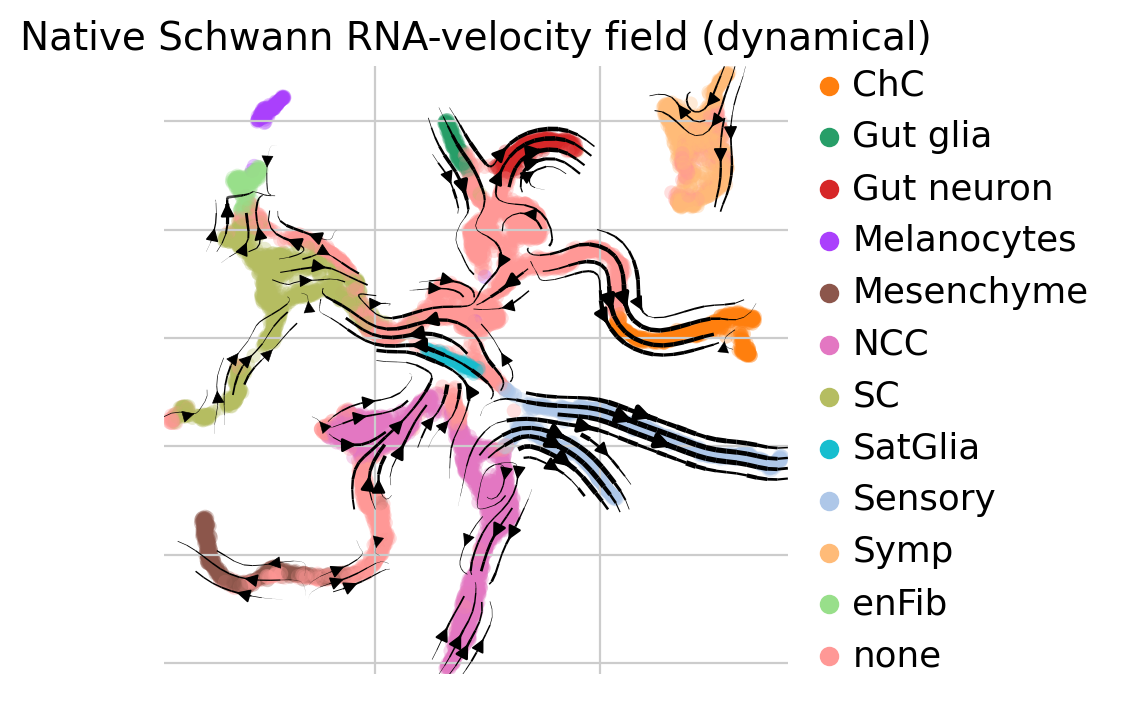

In [4]:
selected_labels = ["Common Progenitor", "Gut", "Gut neuron", "ChC"]
selected_mask_full = adata.obs["cell_type_new"].astype(str).isin(selected_labels)
display(
    adata.obs.loc[
        selected_mask_full,
        ["cell_type_new", "inverse_cytotrace_pseudotime"],
    ]
    .groupby("cell_type_new", observed=True)
    .agg(["count", "median", "min", "max"])
)

color_key = "assignments" if "assignments" in adata.obs else "cell_type_new"
scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    color=color_key,
    legend_loc="right margin",
    title=f"Native Schwann RNA-velocity field ({VELOCITY_MODEL})",
)

## 4. Define the supervised furcation and run preflight diagnostics


In [5]:
ROOT = "Common Progenitor"
FATES = ["Gut", "Gut neuron", "ChC"]
ORDERING_KEY = "inverse_cytotrace_pseudotime"

scorer = scCS.SingleScorer(
    adata,
    root=ROOT,
    branches=FATES,
    obs_key="cell_type_new",
)
preflight = scorer.preflight(ordering_metric=ORDERING_KEY, check_velocity=True)
preflight.display()
preflight.raise_for_errors()
scorer.build_embedding(
    ordering_metric=ORDERING_KEY,
    write_to_adata=True,
)

,level,code,message,value
0,info,furcation_valid,Root and terminal annotations are valid.,1976.000000
1,info,root_cells,Root population contains 675 cells.,675.000000
2,info,terminal_Gut,Terminal 'Gut' contains 245 cells.,245.000000
3,info,terminal_Gut neuron,Terminal 'Gut neuron' contains 294 cells.,294.000000
4,info,terminal_ChC,Terminal 'ChC' contains 762 cells.,762.000000
5,info,ordering_valid,Ordering metric is finite and non-constant amo...,1.000000
6,info,ordering_resolution,Root ordering has 337 unique values across 675...,0.499259
7,info,velocity_available,Velocity information is available.,NaN


[scCS] Scientific star built for 1976 cells in 3 dimensions.
       Root radial clipping: 0.050 low / 0.050 high
       Terminal scientific coordinates: fixed equal-radius simplex vertices (radius=1.000).


## 5. Fit discounted future-fate scoring


In [6]:
FUTURE_OPTIONS = {
    "effective_horizon": 64,
    "anchor_quantile": 0.90,
    "min_anchor_cells": 10,
    "progression_scale": "rank",
    "committed_reach_threshold": 0.25,
    "committed_specificity_threshold": 0.25,
}
scorer.fit(
    scoring_mode="future_fate",
    future_fate_options=FUTURE_OPTIONS,
)
result = scorer.score(write_to_adata=True)
display(pd.Series(result.summary(), name="value").to_frame())
anchor_diagnostics = result.anchor_diagnostics_frame()
display(anchor_diagnostics)
anchor_diagnostics.to_csv(OUTPUT_DIR / "anchor_diagnostics.csv", index=False)

scCS FutureFateScoreResult
  Furcation: Common Progenitor -> ['Gut', 'Gut neuron', 'ChC']
  Effective horizon: 64 (gamma=0.984615)
  Cells: 1976 selected; 675 root
  Root affinity coverage: 1.000
  Root mean future-fate reach: 0.156
  Root mean future-fate entropy: 0.877
  Root mean future-fate specificity: 0.123
  Root mean reach-supported specificity: 0.025
  Root mean unresolved probability: 0.844
  Root mean signed progression: 0.020
  Root future-fate composition: Gut=0.139, Gut neuron=0.365, ChC=0.496
  Solver: direct; iterations=1; residual=3.315e-15
scCS FutureFateScoreResult
  Furcation: Common Progenitor -> ['Gut', 'Gut neuron', 'ChC']
  Effective horizon: 64 (gamma=0.984615)
  Cells: 1976 selected; 675 root
  Root affinity coverage: 1.000
  Root mean future-fate reach: 0.156
  Root mean future-fate entropy: 0.877
  Root mean future-fate specificity: 0.123
  Root mean reach-supported specificity: 0.025
  Root mean unresolved probability: 0.844
  Root mean signed progression: 

,value
0,scCS FutureFateScoreResult\n Furcation: Commo...


,fate,n_anchors,mean_transition_to_same_fate_population,mean_transition_to_root,mean_transition_to_other_selected_fates,mean_transition_outside_selected_path,mean_signed_progression,forward_fraction
0,Gut,26,0.919012,0.046293,0.000000,0.034694,-0.112502,0.0
1,Gut neuron,30,0.879802,0.000610,0.009397,0.110191,-0.123093,0.0
2,ChC,79,0.948219,0.000000,0.000000,0.051781,-0.084801,0.0


## 6. Core star dashboard


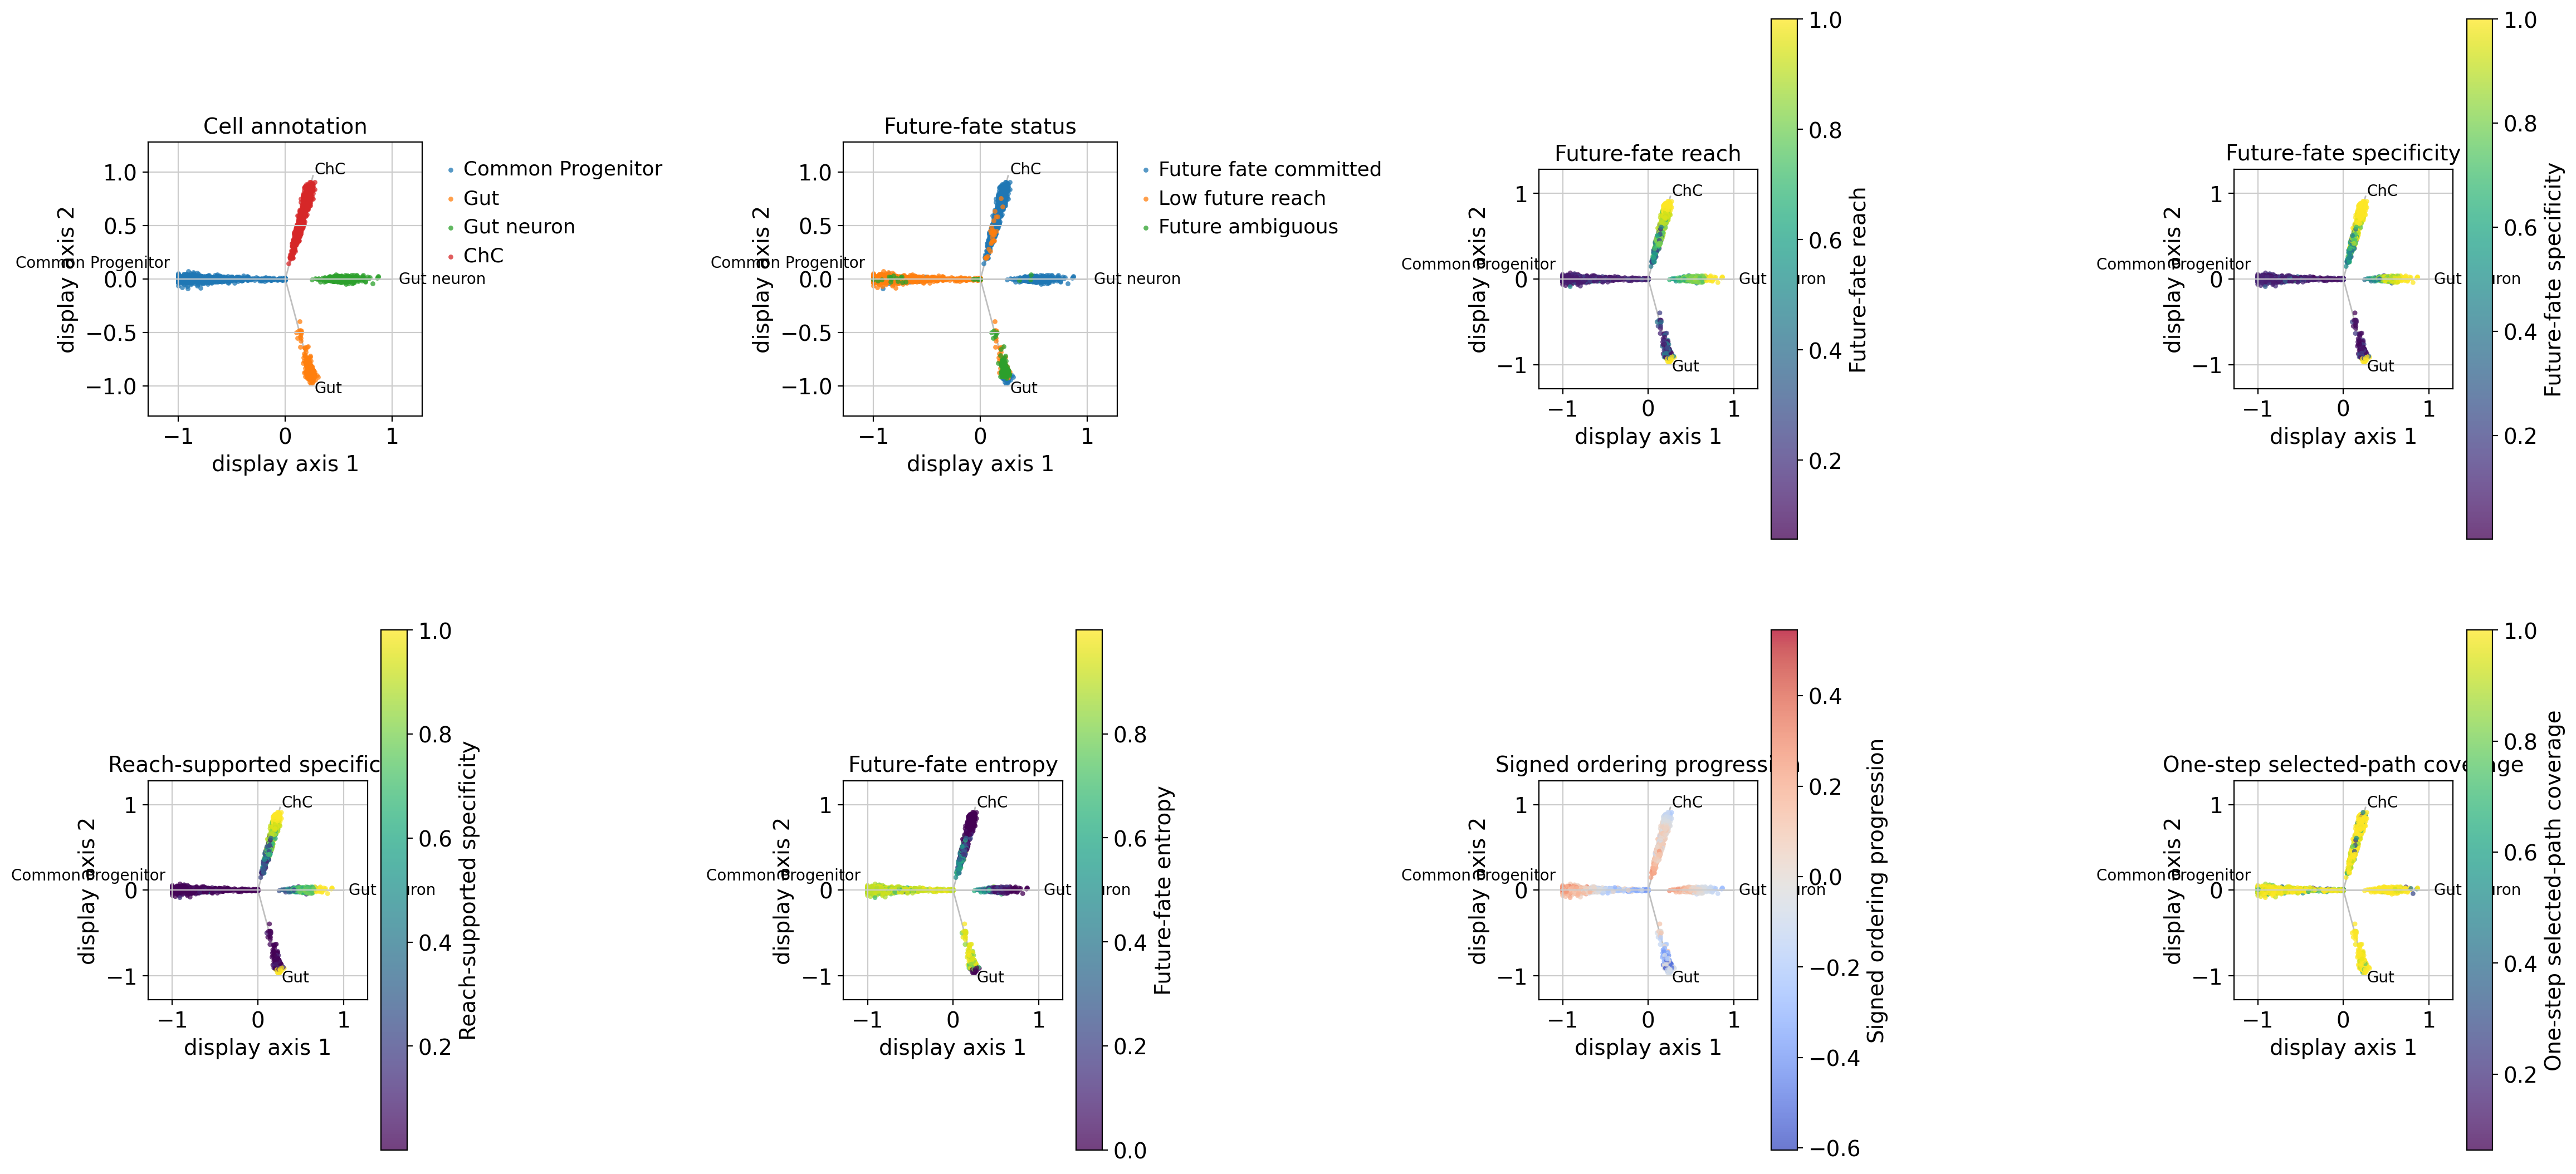

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(23, 11))
scorer.plot_star(result, color_by="population", title="Cell annotation", ax=axes[0, 0])
scorer.plot_star(result, color_by="status", title="Future-fate status", ax=axes[0, 1])
scorer.plot_star(result, color_by="future_fate_reach", title="Future-fate reach", ax=axes[0, 2])
scorer.plot_star(
    result,
    color_by="future_fate_specificity",
    title="Future-fate specificity",
    ax=axes[0, 3],
)
scorer.plot_star(
    result,
    color_by="reach_supported_specificity",
    title="Reach-supported specificity",
    ax=axes[1, 0],
)
scorer.plot_star(result, color_by="future_fate_entropy", title="Future-fate entropy", ax=axes[1, 1])
scorer.plot_star(
    result,
    color_by="signed_progression",
    title="Signed ordering progression",
    cmap="coolwarm",
    ax=axes[1, 2],
)
scorer.plot_star(
    result,
    color_by="selected_path_coverage",
    title="One-step selected-path coverage",
    ax=axes[1, 3],
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "core_star_dashboard.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Fate-specific affinity and contribution


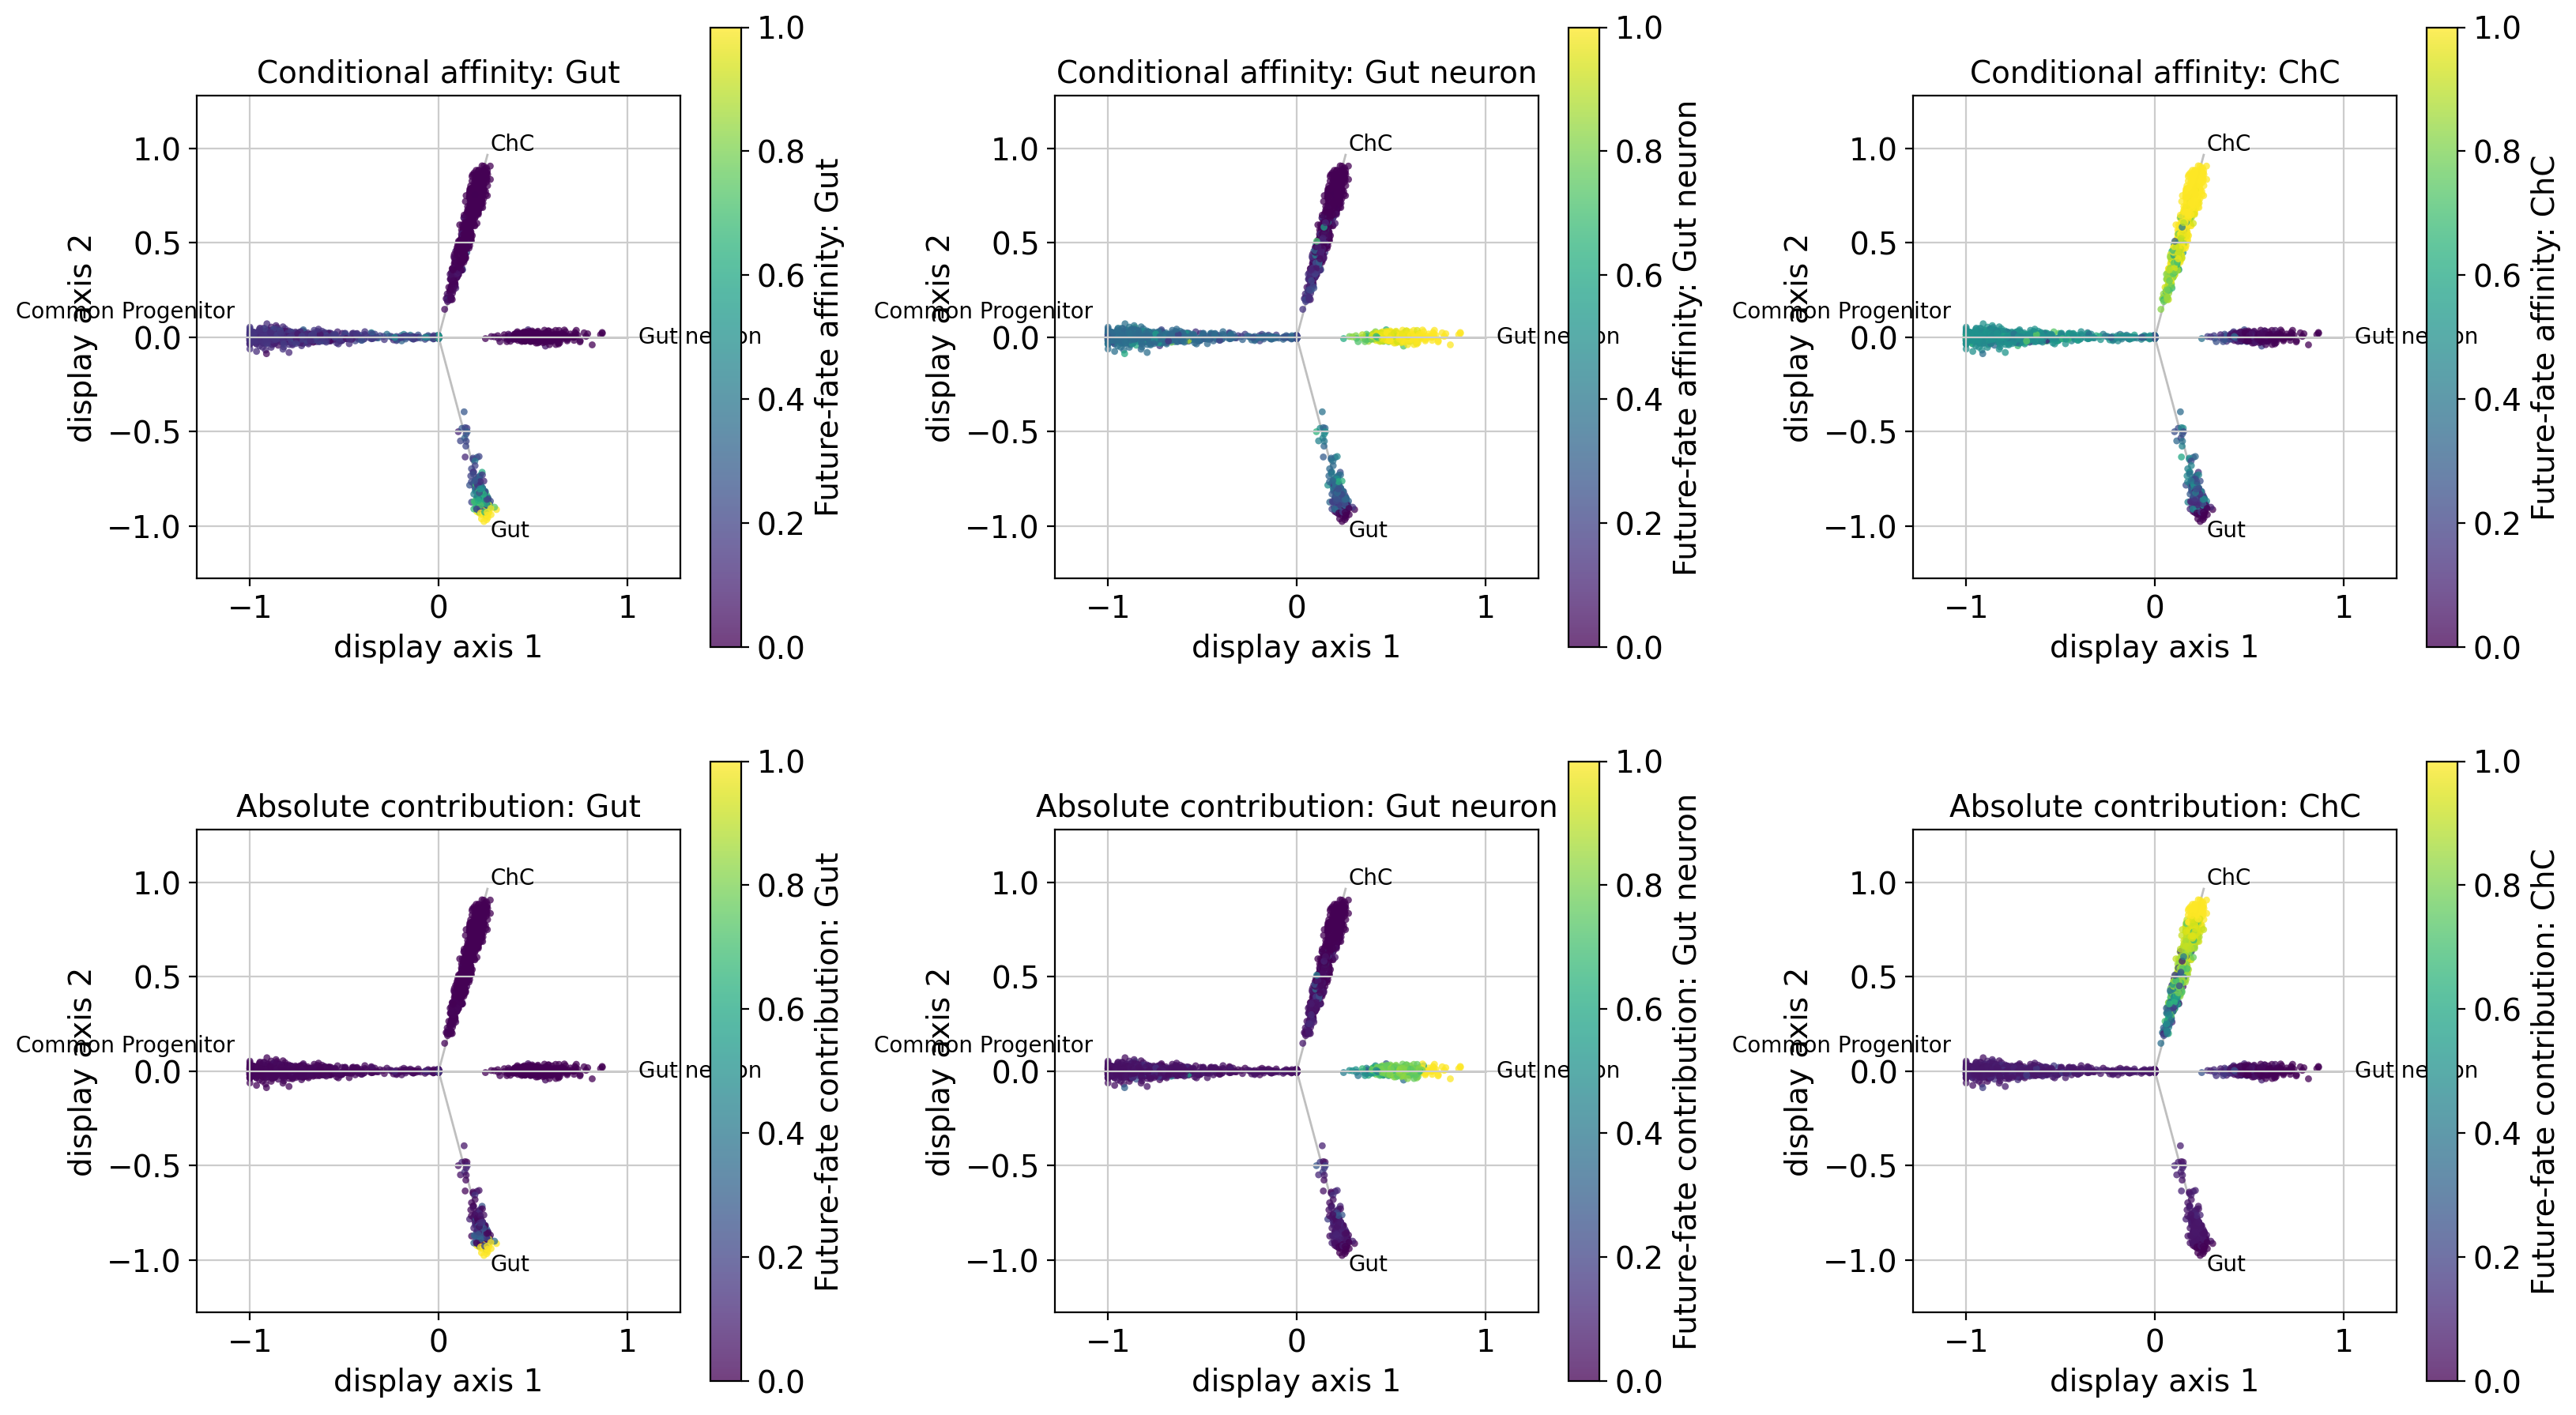

In [8]:
fig, axes = plt.subplots(2, len(FATES), figsize=(5.5 * len(FATES), 9.5))
for column, fate in enumerate(FATES):
    scorer.plot_star(
        result,
        color_by=f"future_fate_affinity:{fate}",
        title=f"Conditional affinity: {fate}",
        ax=axes[0, column],
    )
    scorer.plot_star(
        result,
        color_by=f"future_fate_contribution:{fate}",
        title=f"Absolute contribution: {fate}",
        ax=axes[1, column],
    )
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fate_affinity_and_contribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Heatmaps with cell-type and dominant-affinity strips


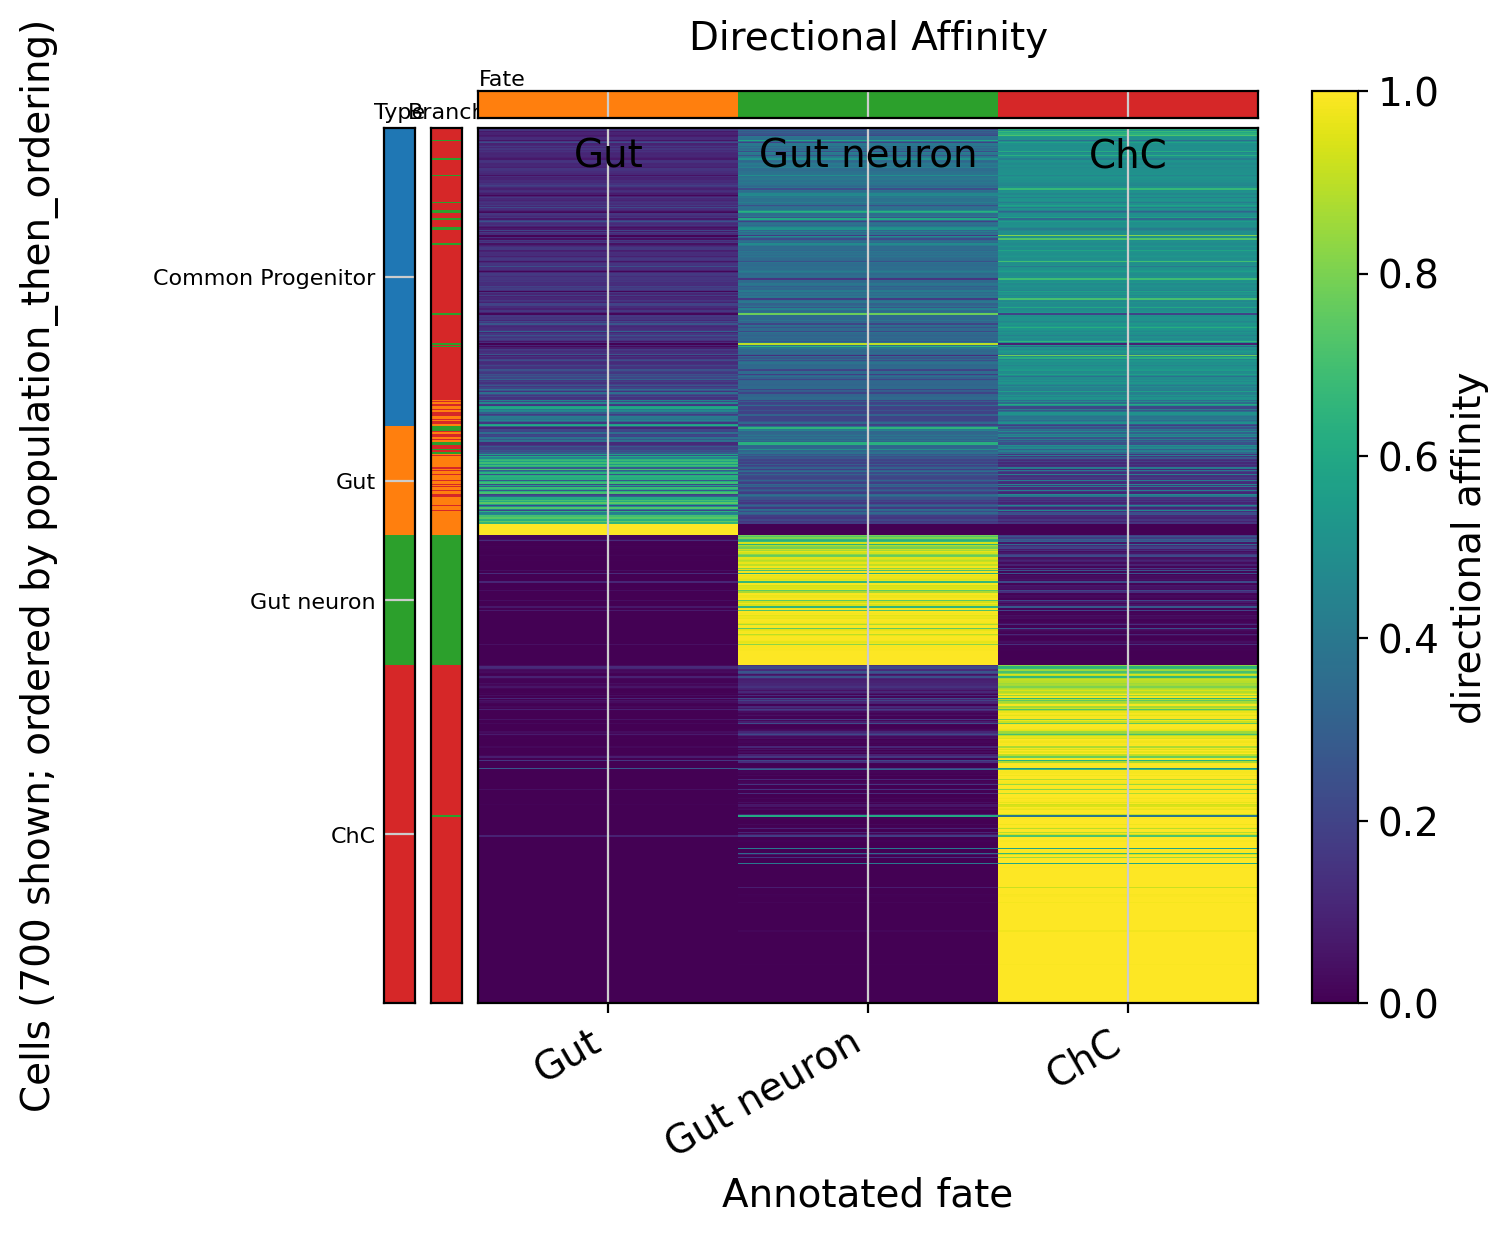

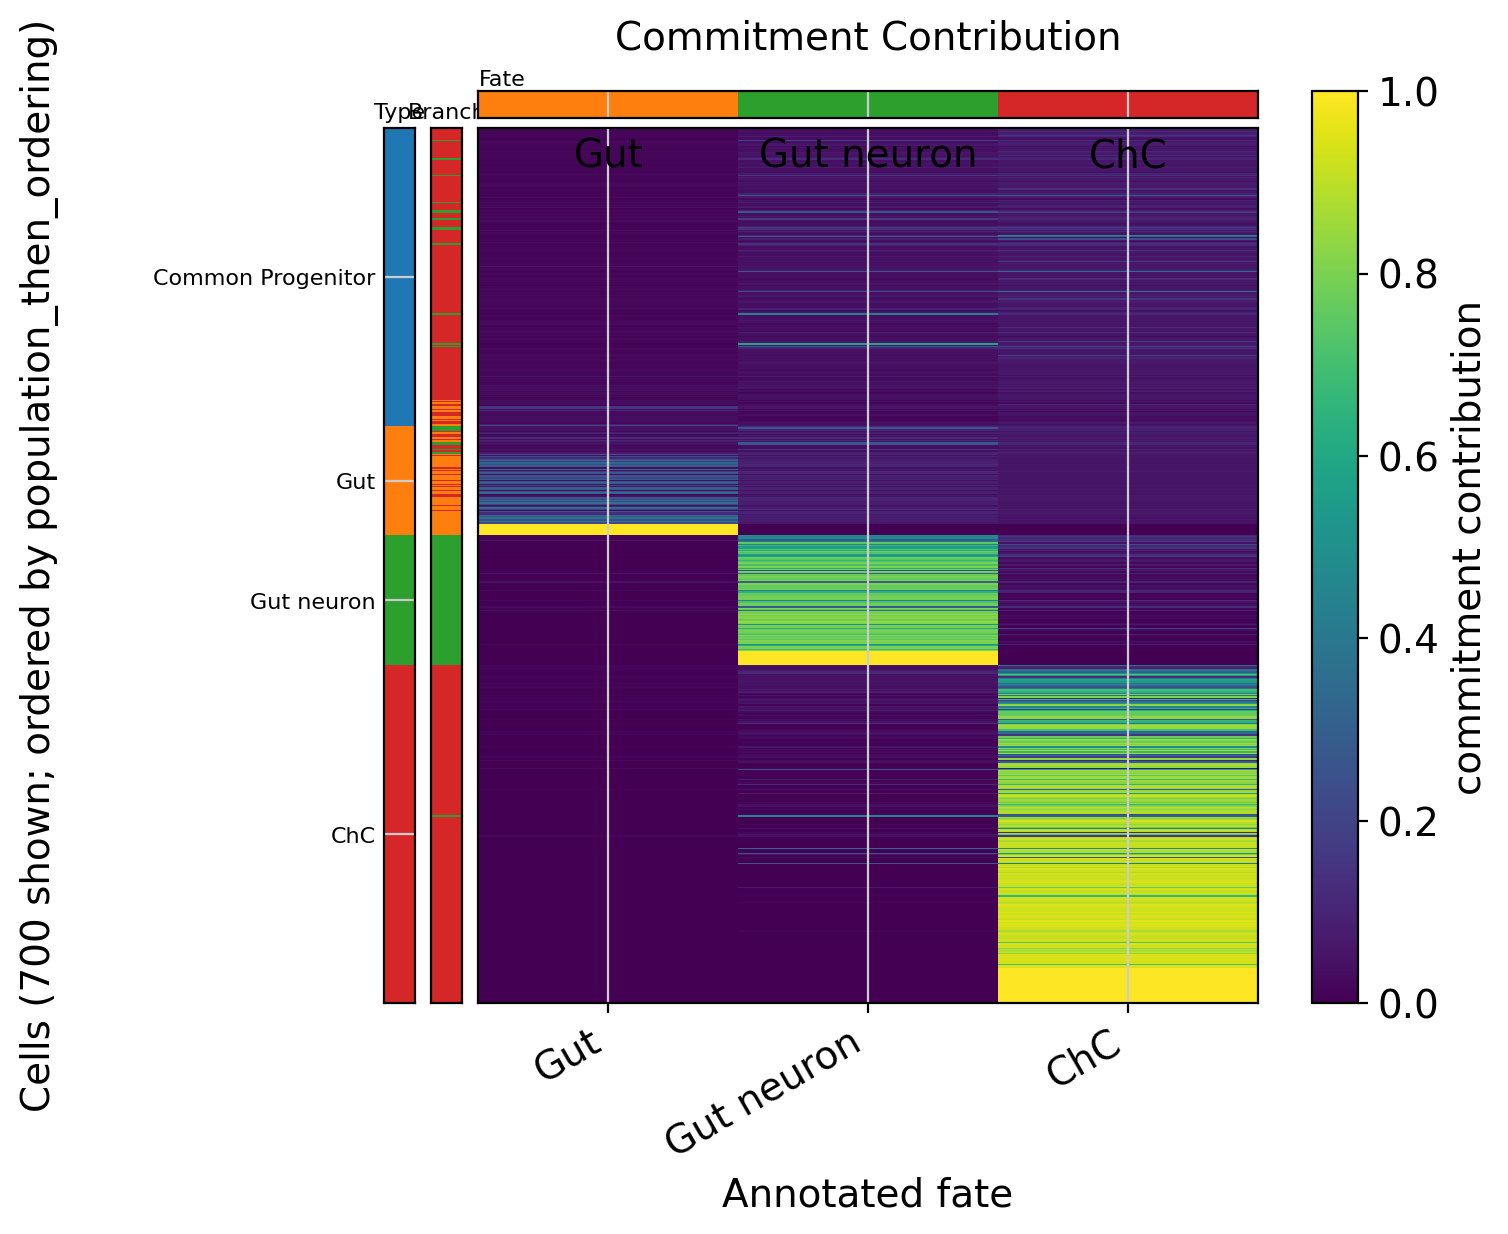

In [9]:
affinity_fig = scorer.plot_commitment_heatmap(
    result,
    metric="future_fate_affinity",
    population="all",
    sort_by="population_then_ordering",
    row_annotation=("population", "dominant_affinity"),
    show_fate_strip=True,
    max_cells=700,
)
affinity_fig.savefig(OUTPUT_DIR / "future_fate_affinity_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

contribution_fig = scorer.plot_commitment_heatmap(
    result,
    metric="future_fate_contribution",
    population="all",
    sort_by="population_then_ordering",
    row_annotation=("population", "dominant_affinity"),
    show_fate_strip=True,
    max_cells=700,
)
contribution_fig.savefig(
    OUTPUT_DIR / "future_fate_contribution_heatmap.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 9. Population summaries and the retrograde Gut result


In [10]:
selected = adata.obs.loc[result.cell_ids].copy()
selected["future_fate_reach"] = result.future_fate_reach
selected["future_fate_specificity"] = result.future_fate_specificity
selected["reach_supported_specificity"] = result.reach_supported_specificity
selected["signed_progression"] = result.signed_progression
selected["ordering_third"] = ordering_thirds(selected[ORDERING_KEY].to_numpy(float))
for fate_index, fate in enumerate(FATES):
    selected[f"affinity_{fate}"] = result.future_fate_affinity[:, fate_index]

population_summary = selected.groupby("cell_type_new", observed=True).agg(
    n_cells=("future_fate_reach", "size"),
    mean_reach=("future_fate_reach", "mean"),
    mean_specificity=("future_fate_specificity", "mean"),
    mean_supported_specificity=("reach_supported_specificity", "mean"),
    mean_progression=("signed_progression", "mean"),
    forward_fraction=("signed_progression", lambda values: float(np.mean(values > 0))),
)
display(population_summary)
population_summary.to_csv(OUTPUT_DIR / "population_summary.csv")

branch_thirds = (
    selected[selected["cell_type_new"].astype(str).isin(FATES)]
    .groupby(["cell_type_new", "ordering_third"], observed=True)
    .agg(
        n_cells=("future_fate_reach", "size"),
        mean_reach=("future_fate_reach", "mean"),
        mean_specificity=("future_fate_specificity", "mean"),
        mean_progression=("signed_progression", "mean"),
        forward_fraction=("signed_progression", lambda values: float(np.mean(values > 0))),
    )
)
display(branch_thirds)
branch_thirds.to_csv(OUTPUT_DIR / "branch_ordering_thirds.csv")

,n_cells,mean_reach,mean_specificity,mean_supported_specificity,mean_progression,forward_fraction
cell_type_new,,,,,,
ChC,762,0.807670,0.874619,0.744100,0.039342,0.674541
Common Progenitor,675,0.155633,0.122960,0.024555,0.020214,0.629630
Gut,245,0.387852,0.211938,0.149273,-0.155898,0.106122
Gut neuron,294,0.779802,0.798632,0.639331,0.029544,0.612245


n_cells  mean_reach  mean_specificity  \
cell_type_new ordering_third                                          
ChC           early               168    0.595579          0.673931   
              late                315    0.935115          0.987162   
              middle              279    0.791490          0.868398   
Gut           early                 1    0.238327          0.009248   
              late                229    0.398183          0.222419   
              middle               15    0.240103          0.065443   
Gut neuron    early                46    0.684211          0.545371   
              late                 19    1.000000          1.000000   
              middle              229    0.780733          0.832798   

                              mean_progression  forward_fraction  
cell_type_new ordering_third                                      
ChC           early                   0.117944          0.928571  
              late                   -0.007118          0.476190  
              middle                  0.044466          0.745520  
Gut           early                   0.111598          1.000000  
              late                   -0.162212          0.091703  
              middle                 -0.077343          0.266667  
Gut neuron    early                   0.128289          0.978261  
              late                   -0.149300          0.000000  
              middle                  0.024547          0.589520

## 10. Population-level composition and pairwise fate balance


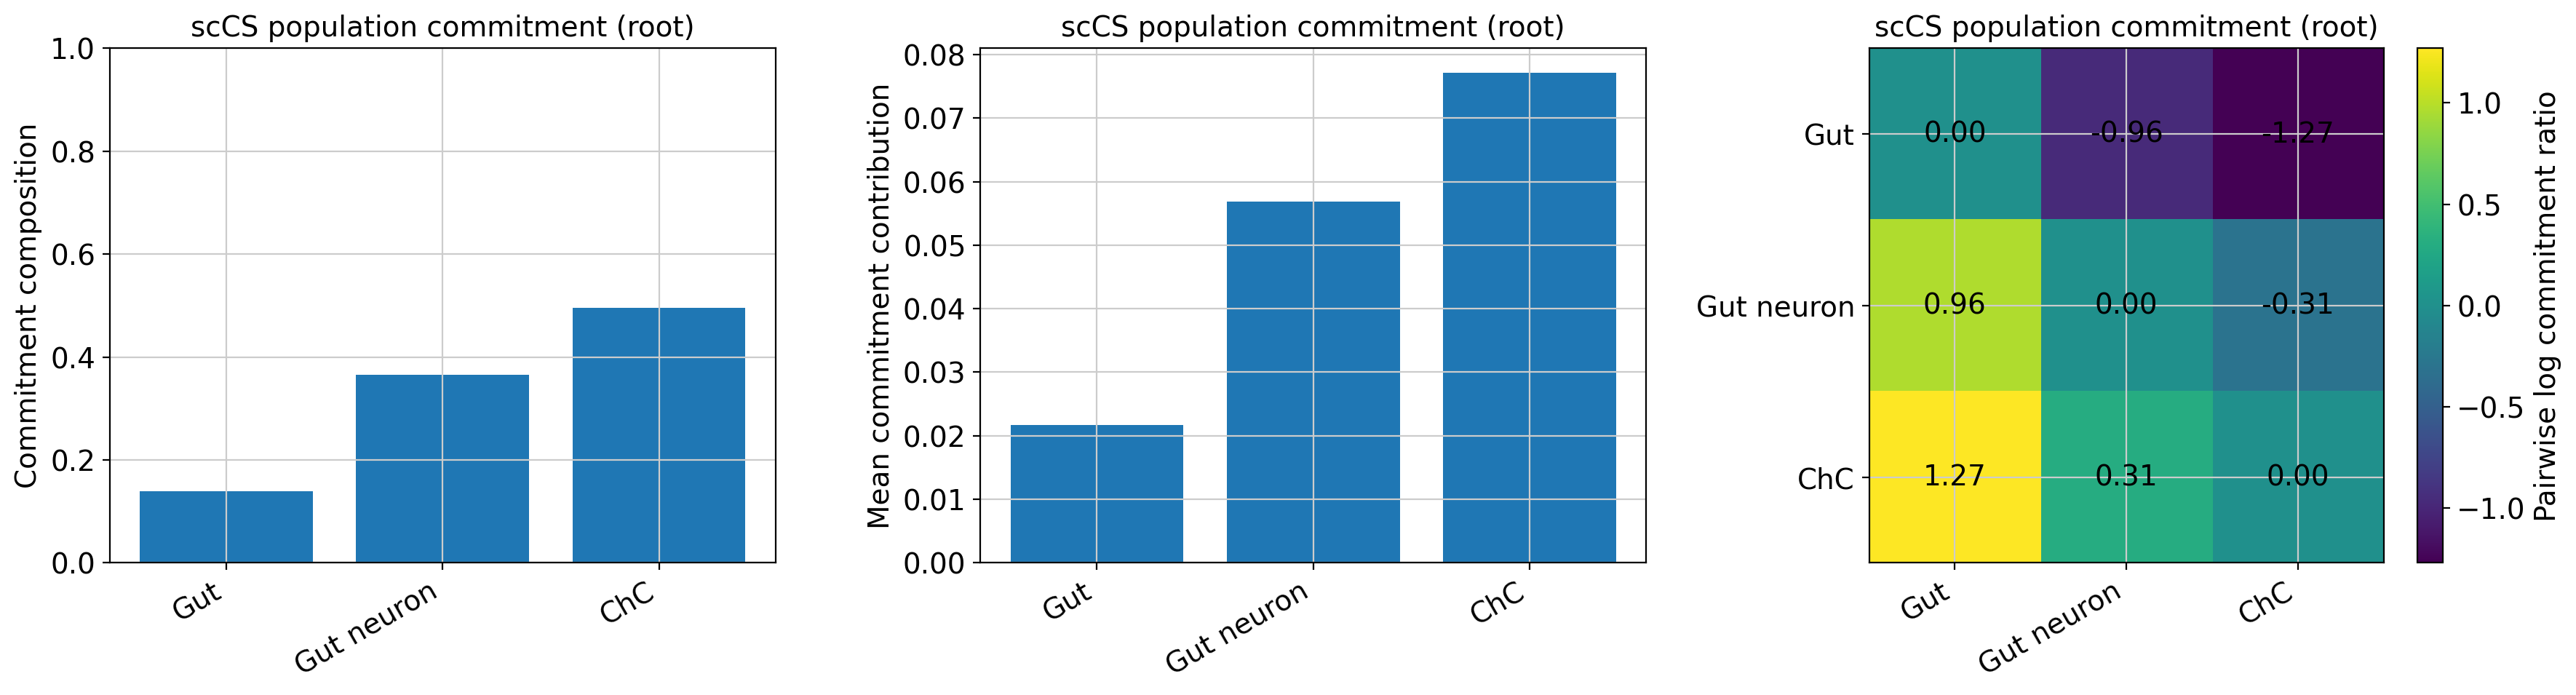

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scorer.plot_commitment_bar(result, population="root", metric="commitment_composition", ax=axes[0])
scorer.plot_population_commitment(
    result,
    population="root",
    metric="mean_commitment_contribution",
    ax=axes[1],
)
scorer.plot_pairwise_cs(result, population="root", ax=axes[2])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "root_population_summaries.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Display-only RNA-velocity diagnostics

The primary scCS result above is the discounted future-fate model. The figures below are optional RNA-velocity quality-control views. They use a separate instantaneous scorer and therefore do **not** define future-fate affinity, reach, specificity, or entropy.

A straight star cannot preserve every turn or loop of the original manifold. We therefore show (1) the native scVelo projection on the star, (2) a root fate-directed rose after removing incoming-root progression, and (3) separate branch-relative roses in which each annotated terminal population retains its identity. In the branch-relative panels, outward is 0°, transverse motion is ±90°, and inward motion is 180°.


,n_cells,mean_own_future_fate_affinity,mean_future_fate_reach,mean_signed_progression
fate,,,,
Gut,245,0.516848,0.387852,-0.155898
Gut neuron,294,0.925179,0.779802,0.029544
ChC,762,0.951905,0.807670,0.039342


computing velocity embedding
    finished (0:00:00)


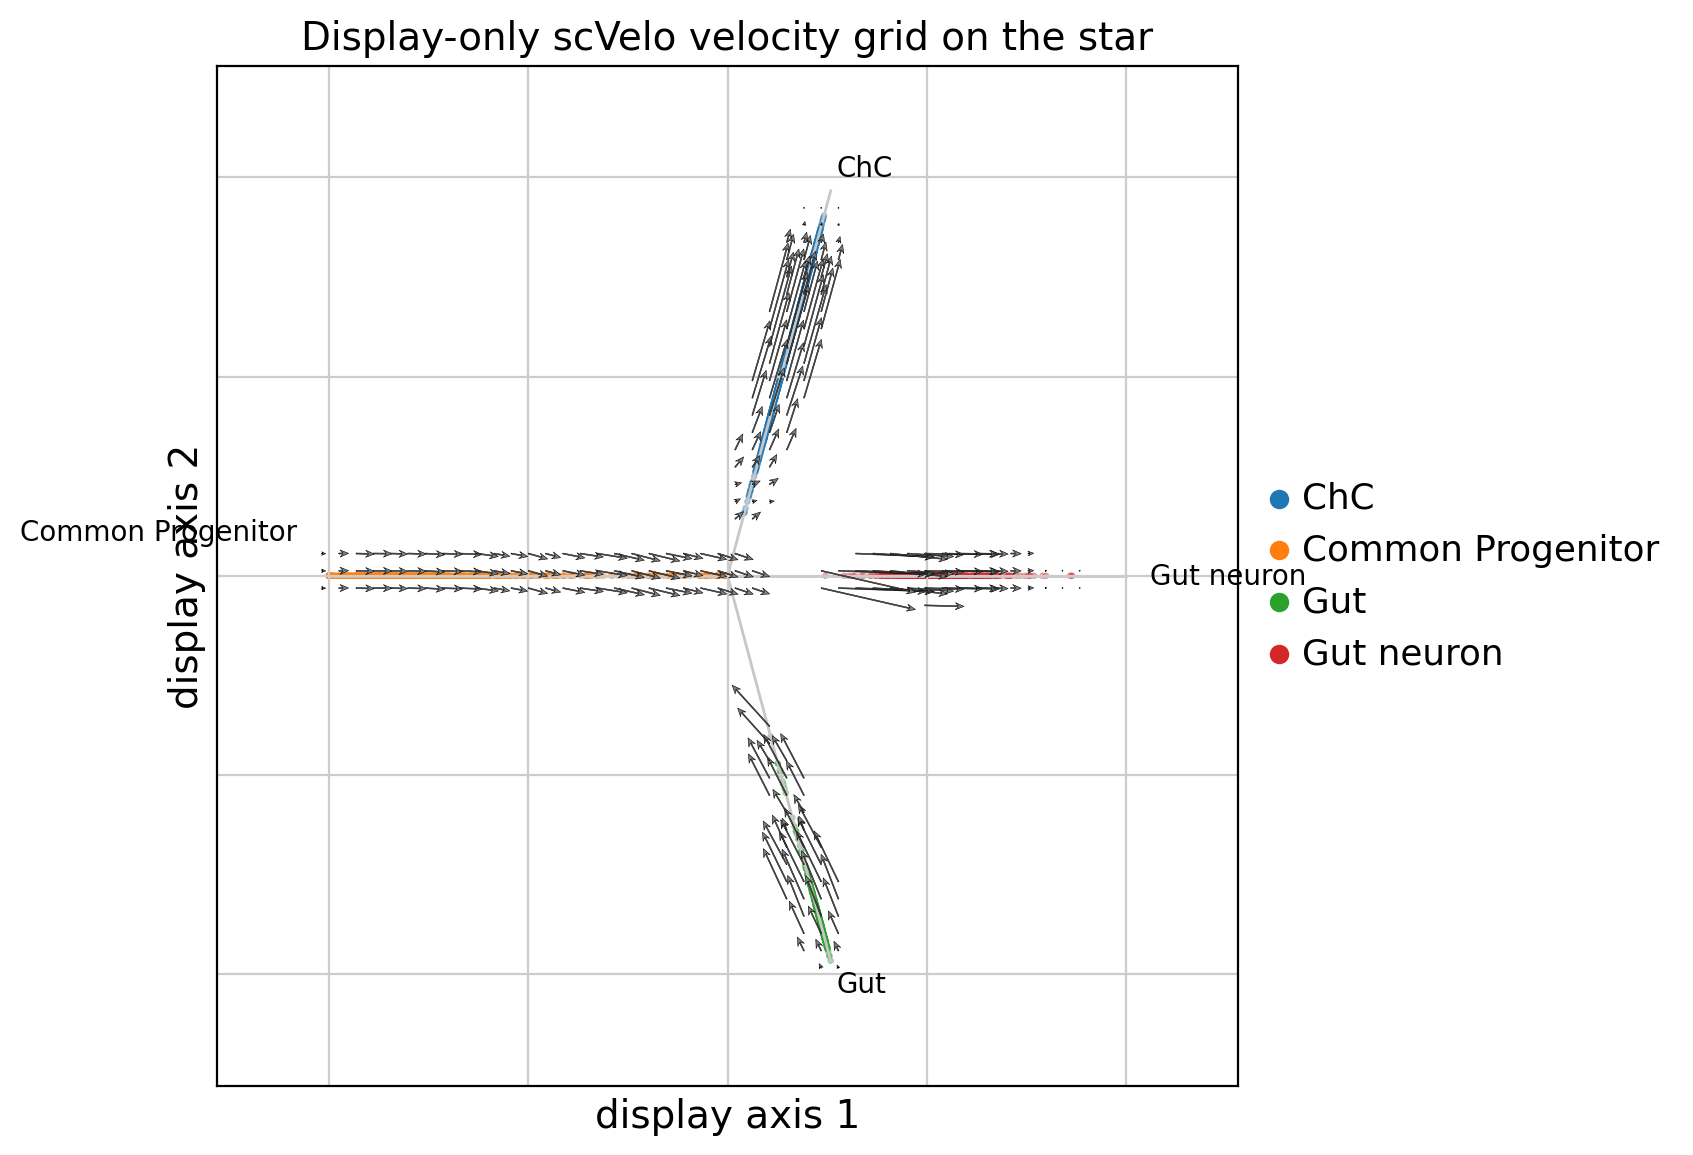

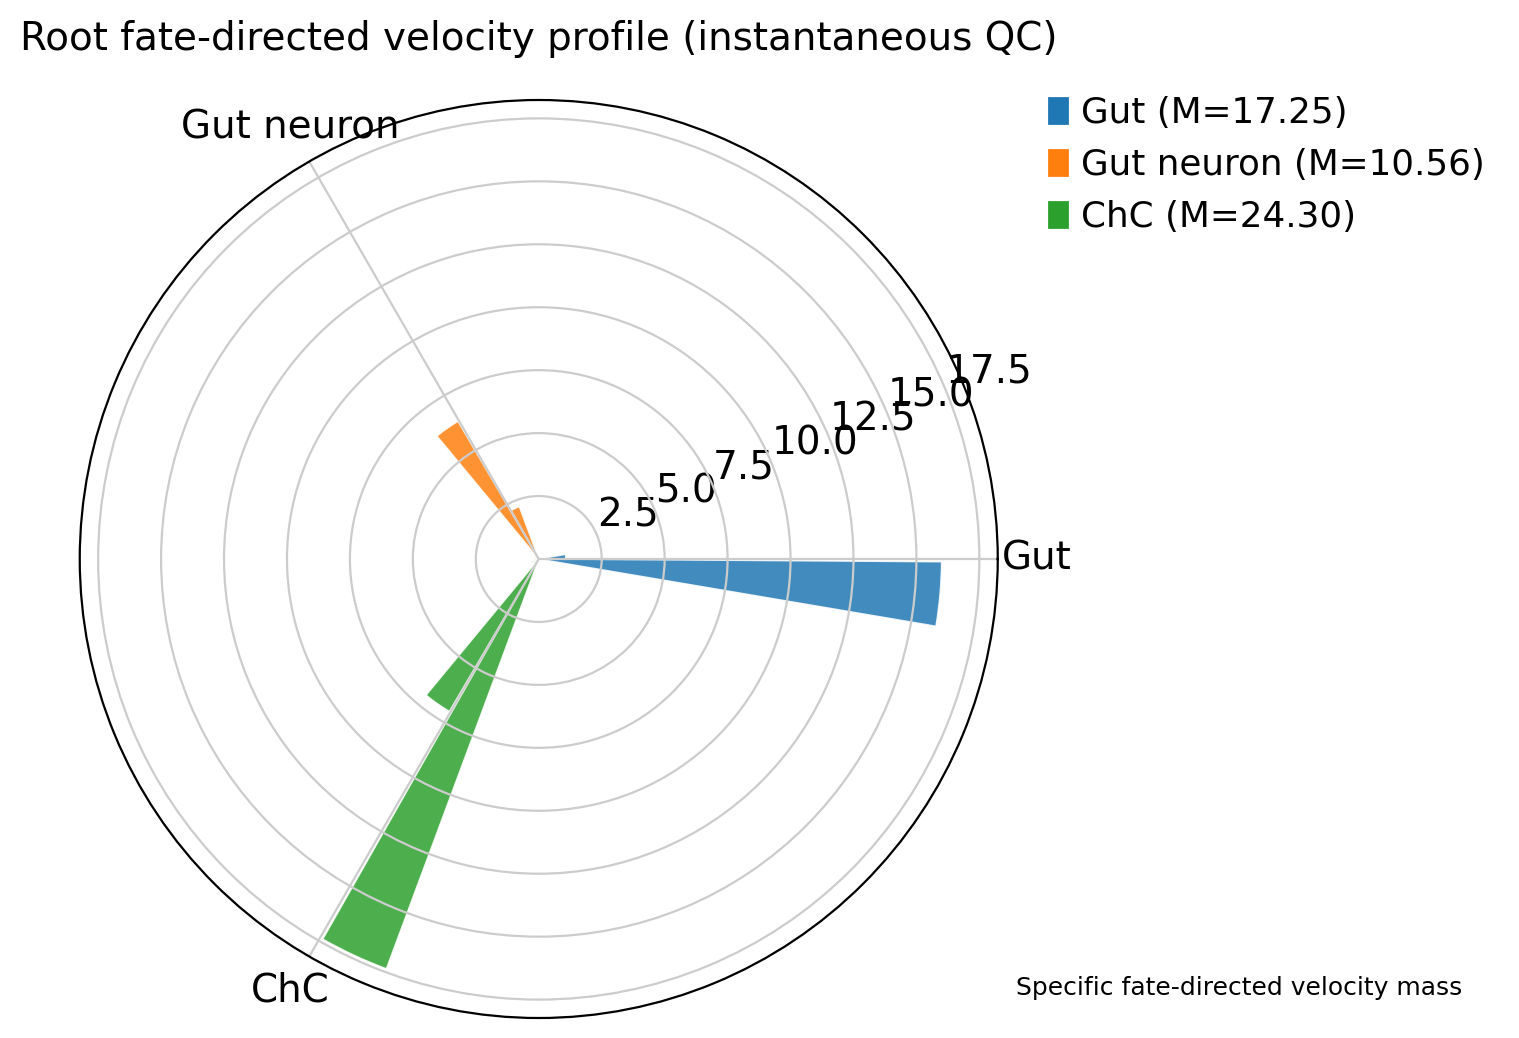

computing velocity embedding
    finished (0:00:00)


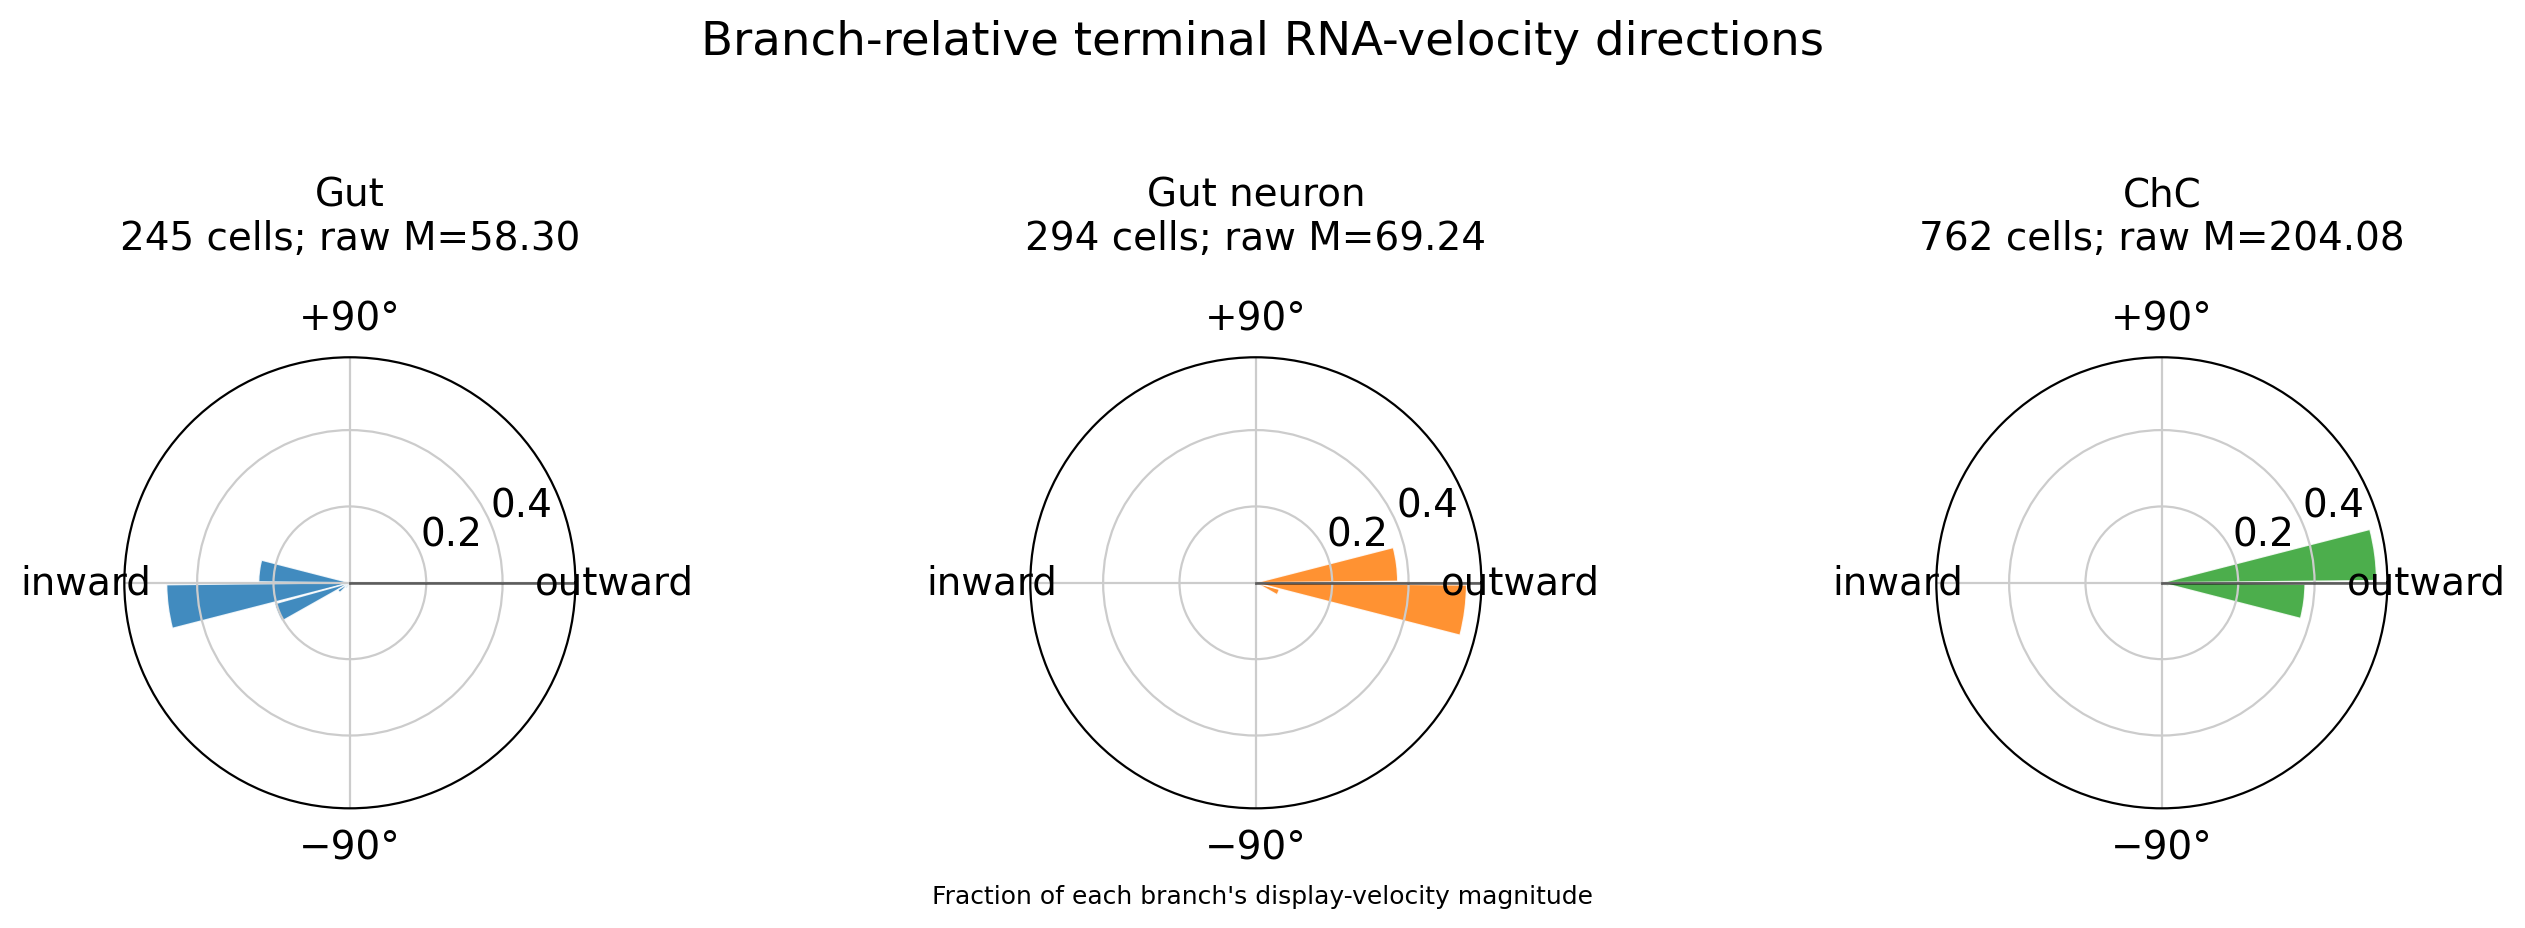

In [12]:
# First summarize the scientific future-fate result. This table and the root
# future-fate composition plot answer which fate is dominant. Display-space
# arrows answer a different question and can be curved or retrograde.
terminal_labels = np.asarray(result.embedding.selected_labels).astype(str)
terminal_qc_rows = []
for fate_index, fate in enumerate(FATES):
    fate_mask = result.terminal_mask & (terminal_labels == fate)
    terminal_qc_rows.append(
        {
            "fate": fate,
            "n_cells": int(fate_mask.sum()),
            "mean_own_future_fate_affinity": float(
                np.nanmean(result.future_fate_affinity[fate_mask, fate_index])
            ),
            "mean_future_fate_reach": float(np.nanmean(result.future_fate_reach[fate_mask])),
            "mean_signed_progression": float(np.nanmean(result.signed_progression[fate_mask])),
        }
    )
display(pd.DataFrame(terminal_qc_rows).set_index("fate"))

# Build a separate instantaneous scorer only for RNA-velocity display QC.
# This does not alter the primary discounted future-fate result.
instantaneous_display_scorer = scCS.SingleScorer(
    adata,
    root=ROOT,
    branches=FATES,
    obs_key="cell_type_new",
)
instantaneous_display_scorer.build_embedding(
    ordering_metric=ORDERING_KEY,
    write_to_adata=True,
    verbose=False,
)
instantaneous_display_scorer.fit(scoring_mode="instantaneous", verbose=False)
instantaneous_display_result = instantaneous_display_scorer.score(
    write_to_adata=False,
    verbose=False,
)

# Native scVelo projection onto the straightened star. Curved, loop-like, or
# retrograde source trajectories can therefore look inward on some branches.
fig, ax = plt.subplots(figsize=(8, 6))
instantaneous_display_scorer.plot_velocity_embedding_grid(
    instantaneous_display_result,
    population="all",
    density=0.9,
    smooth=0.55,
    min_mass=1.0,
    n_neighbors=50,
    projection_mode="scvelo",
    title="Display-only scVelo velocity grid on the star",
    ax=ax,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "display_velocity_grid.png", dpi=200, bbox_inches="tight")
plt.show()

# Root fate-directed velocity after removing incoming-root progression. This
# is the closest analogue of the familiar binned commitment rose and does not
# assign the incoming root direction to a terminal sector.
root_rose = plt.figure(figsize=(8.5, 6.5))
root_rose_ax = root_rose.add_subplot(111, projection="polar")
instantaneous_display_scorer.plot_rose(
    instantaneous_display_result,
    population="root",
    mode="branch",
    n_bins=36,
    normalization="mass",
    title="Root fate-directed velocity profile (instantaneous QC)",
    ax=root_rose_ax,
)
root_rose.subplots_adjust(right=0.72)
root_rose.savefig(OUTPUT_DIR / "root_branch_velocity_rose.png", dpi=200, bbox_inches="tight")
plt.show()

# Terminal branches are shown separately. Each panel keeps cells attached to
# their annotated branch: 0° is outward, ±90° is transverse, and 180° is
# inward. Thus a retrograde Delta, Epsilon, or Gut vector is never relabeled as
# movement toward a different fate merely because of the 2D star layout.
branch_profiles = instantaneous_display_scorer.plot_branch_velocity_profiles(
    instantaneous_display_result,
    n_bins=24,
    normalization="within_branch",
    projection_mode="scvelo",
    title="Branch-relative terminal RNA-velocity directions",
)
branch_profiles.savefig(
    OUTPUT_DIR / "branch_relative_velocity_profiles.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 12. Gene expression on the star


Resolved markers: ['Phox2b', 'Tubb3', 'Elavl3', 'Chga', 'Chgb', 'Dbh']
Missing markers: ['Sox10', 'Foxd3', 'Th']


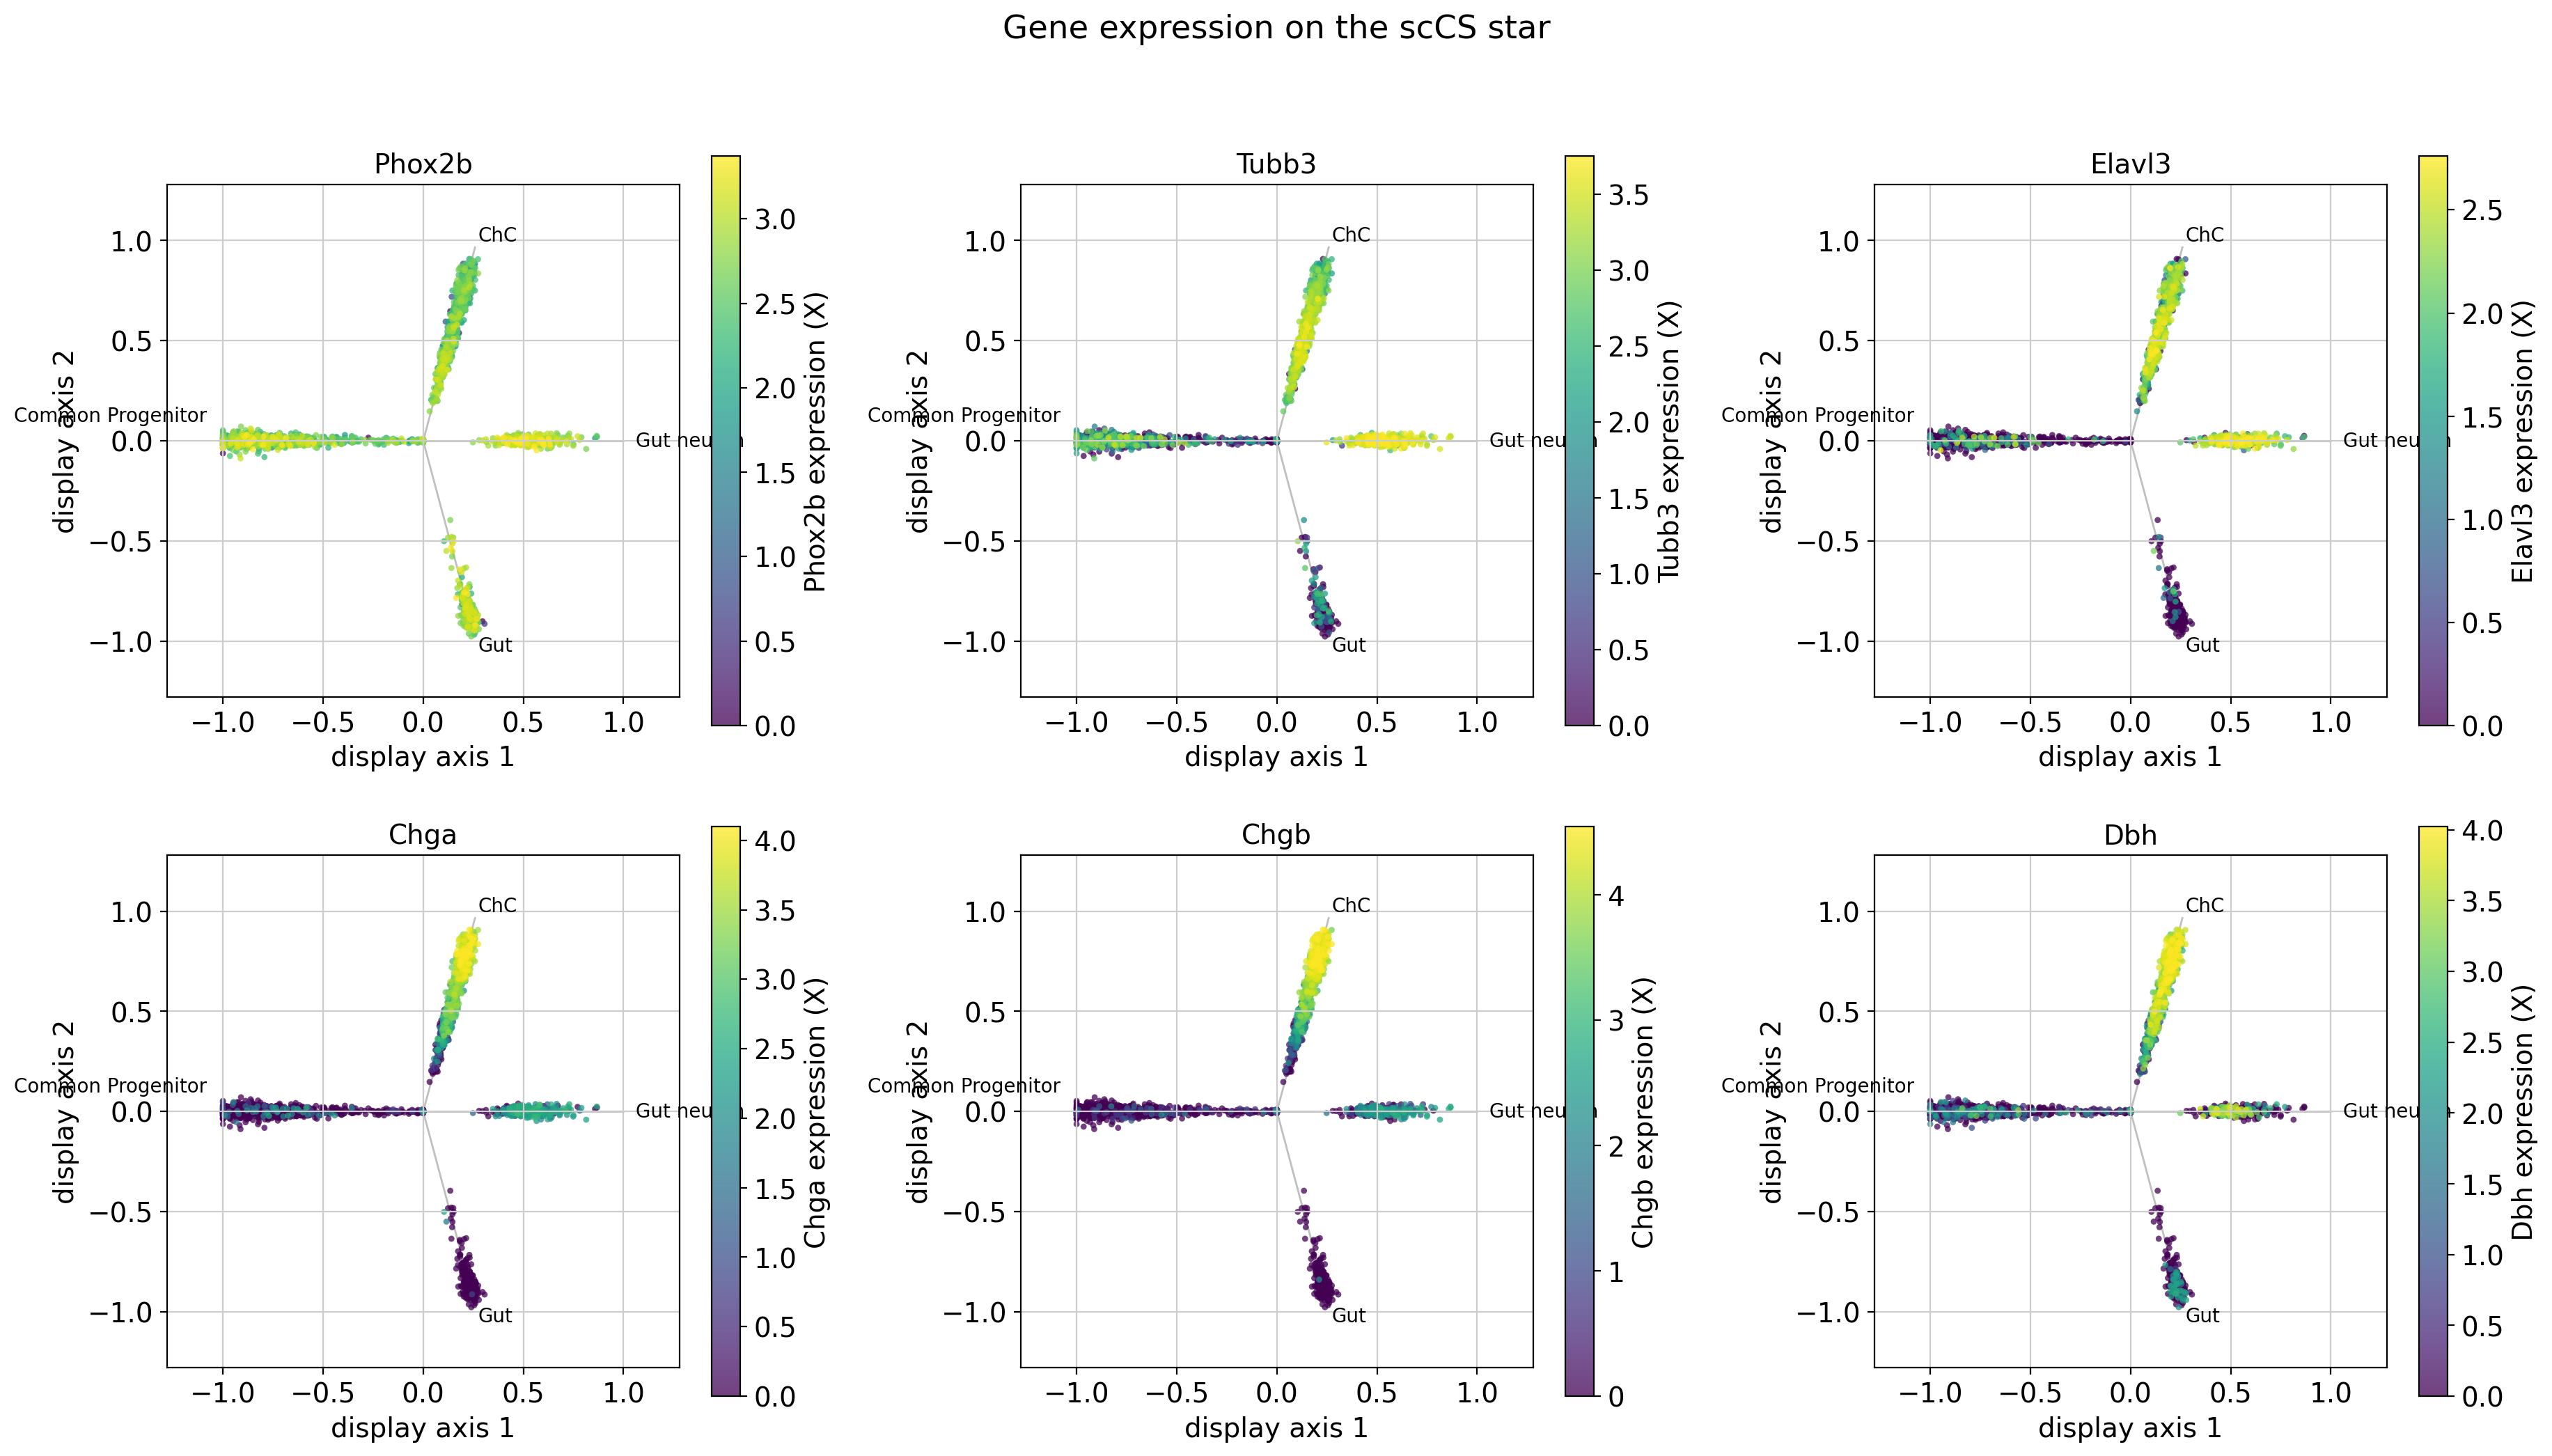

In [13]:
marker_candidates = [
    "Sox10",
    "Foxd3",
    "Phox2b",
    "Tubb3",
    "Elavl3",
    "Chga",
    "Chgb",
    "Th",
    "Dbh",
]
markers, missing_markers = resolve_present_genes(adata, marker_candidates)
print("Resolved markers:", markers)
print("Missing markers:", missing_markers)
if markers:
    marker_fig = scorer.plot_gene_expression_star(
        markers,
        result,
        ncols=3,
        shared_scale=False,
        terminal_layout="ordering",
    )
    marker_fig.savefig(OUTPUT_DIR / "marker_expression_stars.png", dpi=200, bbox_inches="tight")
    plt.show()

## 13. Expression trends and exploratory gene associations


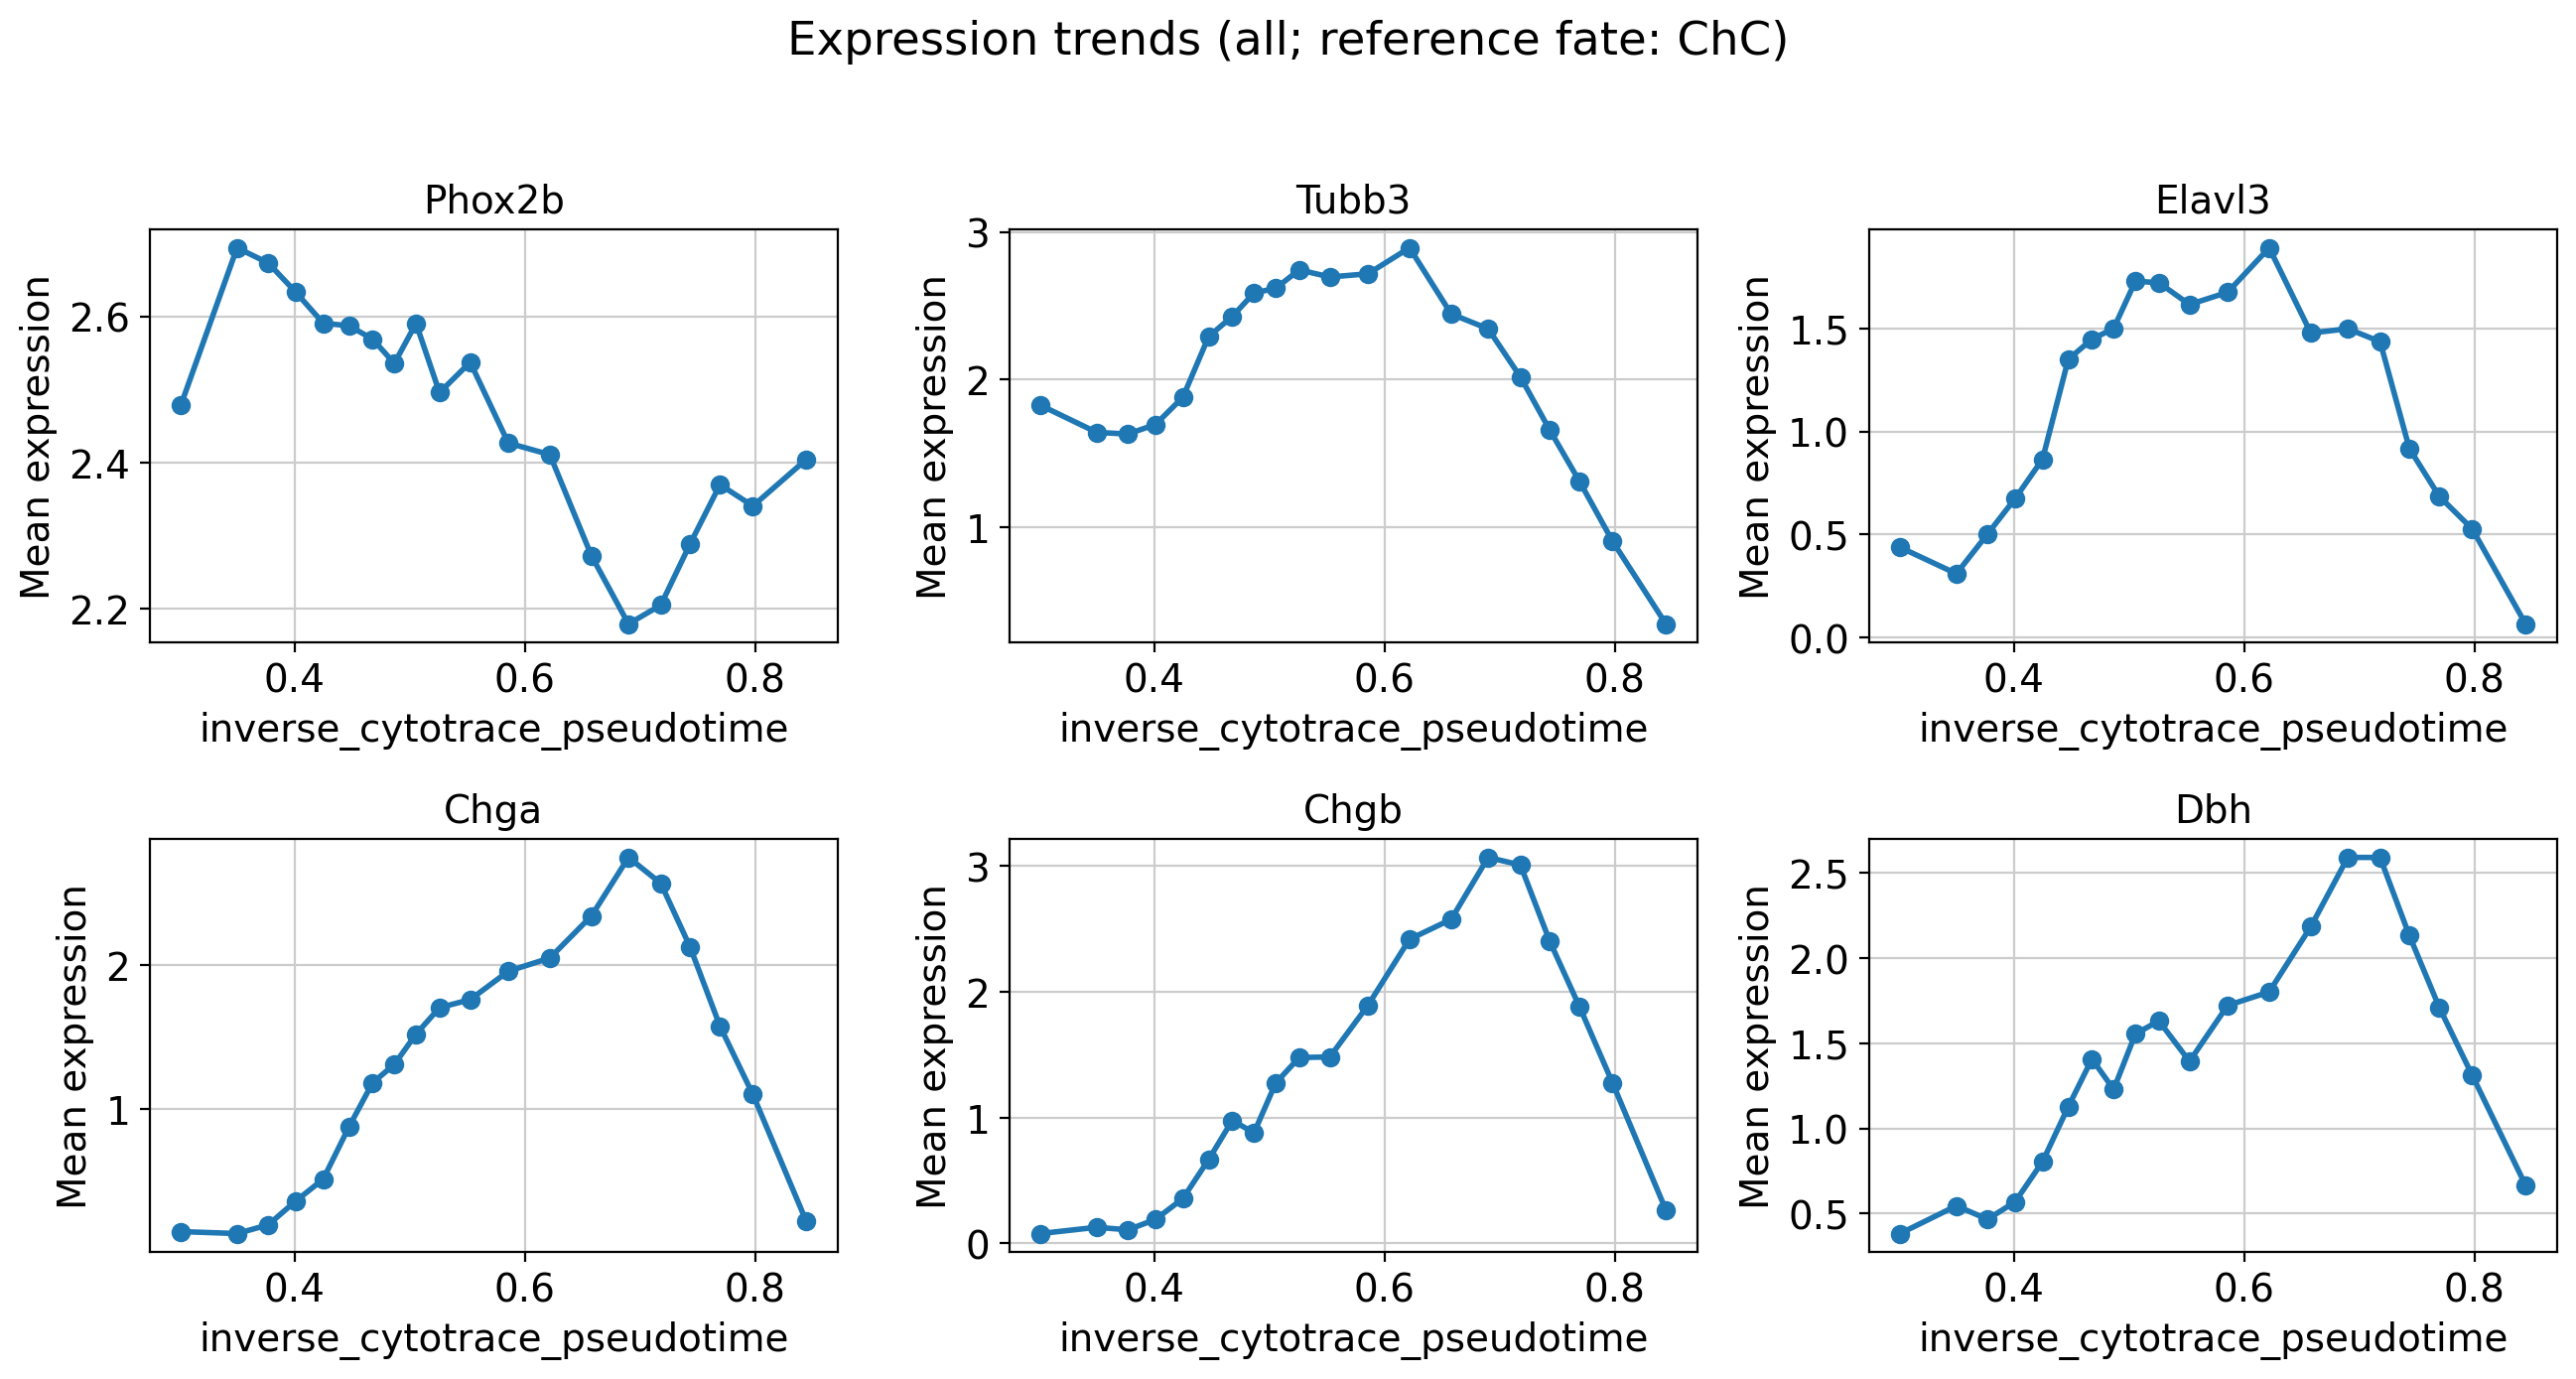


[scCS] Candidate commitment-associated genes: Gut
        inference_unit=cell_exploratory; matrix=X; n_units=675; tested_genes=811
 rank    gene   effect   pvalue_adj  significant
    1  Col5a1 0.485261 3.373593e-38         True
    2   Lama4 0.459167 7.590007e-34         True
    3   Hspg2 0.438345 1.377937e-30         True
    4    Mcam 0.433175 6.778292e-30         True
    5   Lamb1 0.410938 1.230403e-26         True
    6 Col18a1 0.372944 1.160676e-21         True
    7  Tagln2 0.369894 2.515631e-21         True
    8   Sparc 0.357539 5.845513e-20         True
    9  Sorbs1 0.337323 1.150607e-17         True
   10  Camk2b 0.332076 3.902908e-17         True
   11   Postn 0.332067 3.902908e-17         True
   12   Wwtr1 0.328782 8.119904e-17         True
   13 Micall1 0.328721 8.119904e-17         True
   14    Ngfr 0.322114 3.959277e-16         True
   15   Lamc1 0.314530 2.240800e-15         True
   16    Utrn 0.308363 9.123179e-15         True
   17  Col4a2 0.308078 9.342270e-15

,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Col5a1,0.485261,4.159794e-41,3.373593e-38,1.964407,0.947295,579,675,True,0.485261,1
1,Lama4,0.459167,1.871765e-36,7.590007e-34,1.773734,1.000479,544,675,True,0.459167,2
2,Hspg2,0.438345,5.097178e-33,1.377937e-30,0.918172,0.899727,378,675,True,0.438345,3
3,Mcam,0.433175,3.343177e-32,6.778292e-30,2.143249,0.945579,590,675,True,0.433175,4
4,Lamb1,0.410938,7.585717e-29,1.230403e-26,1.813068,0.940148,563,675,True,0.410938,5
5,Col18a1,0.372944,1.144933e-23,1.160676e-21,1.921003,0.971373,572,675,True,0.372944,6
6,Tagln2,0.369894,2.791699e-23,2.515631e-21,2.127654,1.016963,574,675,True,0.369894,7
7,Sparc,0.357539,9.370120e-22,5.845513e-20,2.890668,0.471350,668,675,True,0.357539,8
8,Sorbs1,0.337323,2.128126e-19,1.150607e-17,1.455308,1.035056,482,675,True,0.337323,9
9,Camk2b,0.332076,8.163270e-19,3.902908e-17,1.493340,0.928660,524,675,True,0.332076,10



 Gut neuron


,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Chrnb4,0.363621,1.693978e-22,1.717270e-20,0.884235,1.126394,282,675,True,0.363621,1
1,Celf2,0.309912,1.803967e-16,4.876724e-15,2.413041,0.481743,664,675,True,0.309912,2
2,Serpini1,0.296371,3.929374e-15,8.386112e-14,1.026285,1.147788,323,675,True,0.296371,3
3,Rbp1,0.291200,1.221914e-14,2.477431e-13,3.046686,0.412748,673,675,True,0.291200,4
4,Dll1,0.285390,4.252479e-14,7.663913e-13,0.642346,1.004160,214,675,True,0.285390,5
5,Cd9,0.272488,6.123400e-13,1.056612e-11,2.153465,0.689199,631,675,True,0.272488,6
6,Phox2b,0.257167,1.215364e-11,1.699414e-10,2.511418,0.507439,666,675,True,0.257167,7
7,Slc18a2,0.251240,3.668521e-11,4.958618e-10,1.369748,1.047893,460,675,True,0.251240,8
8,Ednrb,0.245161,1.106423e-10,1.359559e-09,3.201430,0.363540,675,675,True,0.245161,9
9,Eya1,0.239936,2.791368e-10,3.107756e-09,1.019634,0.999943,379,675,True,0.239936,10



 ChC


,gene,effect,pvalue,pvalue_adj,feature_mean,feature_sd,n_detected_cells,n_units,significant,absolute_effect,rank
0,Gata3,0.320293,1.521948e-17,6.171498e-15,0.256525,0.683459,95,675,True,0.320293,1
1,Tbx20,0.265919,2.257416e-12,4.297022e-10,0.157420,0.546793,60,675,True,0.265919,2
2,Htr3a,0.265101,2.649212e-12,4.297022e-10,0.220528,0.710026,66,675,True,0.265101,3
3,Cdkn1c,0.253558,2.389436e-11,2.520190e-09,2.755475,0.681492,668,675,True,0.253558,4
4,Tfap2b,0.225580,3.179907e-09,2.578904e-07,0.435354,0.732454,198,675,True,0.225580,5
5,Pls3,0.206909,5.944413e-08,3.957827e-06,2.281151,0.961091,596,675,True,0.206909,6
6,Zdbf2,0.206474,6.344236e-08,3.957827e-06,0.520088,0.832358,208,675,True,0.206474,7
7,Adam23,0.203170,1.035380e-07,5.997808e-06,0.961757,0.977666,372,675,True,0.203170,8
8,Scrg1,0.200918,1.439102e-07,7.780744e-06,0.359461,0.726299,142,675,True,0.200918,9
9,Padi2,0.194298,3.706797e-07,1.582217e-05,0.652577,0.964456,229,675,True,0.194298,10


['tutorial_outputs/schwann_single/future_fate_gene_association_Gut.csv',
 'tutorial_outputs/schwann_single/future_fate_gene_association_Gut_neuron.csv',
 'tutorial_outputs/schwann_single/future_fate_gene_association_ChC.csv',
 'tutorial_outputs/schwann_single/future_fate_gene_association_metadata.json']

In [14]:
if markers:
    trend_fig = scorer.plot_expression_trends(
        markers,
        result,
        x_axis="ordering",
        population="all",
        n_bins=20,
        ncols=3,
    )
    trend_fig.savefig(OUTPUT_DIR / "marker_expression_trends.png", dpi=200, bbox_inches="tight")
    plt.show()

association = scorer.get_commitment_associated_genes(
    outcome="future_fate_affinity",
    fate_names=FATES,
    population="root",
    inference_unit="cell_exploratory",
    pseudotime_key=ORDERING_KEY,
    min_cells=100,
    min_feature_cells=10,
    min_feature_fraction=0.01,
    n_top_genes=30,
    verbose=True,
)
for fate in FATES:
    print("\n", fate)
    display(association.top(fate, n=15))
association.export(OUTPUT_DIR, prefix="future_fate_gene_association")

## 14. Optional replicate-aware gene association

The RegVelo object may contain plate or sample metadata. A plate-level analysis is
only appropriate when the units are sufficiently numerous and scientifically
defensible; plate can be confounded with developmental time. The code below runs
only when a usable key is present.


In [15]:
replicate_candidates = [key for key in ("plate", "sample", "sample_id") if key in adata.obs]
if replicate_candidates:
    replicate_key = replicate_candidates[0]
    root_units = adata.obs.loc[result.cell_ids[result.root_mask], replicate_key].astype(str)
    unit_counts = root_units.value_counts()
    eligible = unit_counts[unit_counts >= 5]
    print("Candidate replicate key:", replicate_key)
    display(unit_counts.to_frame("root_cells"))
    if len(eligible) >= 6:
        replicate_association = scorer.get_commitment_associated_genes(
            outcome="future_fate_affinity",
            fate_names=FATES,
            population="root",
            inference_unit="replicate",
            replicate_key=replicate_key,
            pseudotime_key=None,
            min_replicates=6,
            min_cells_per_replicate=5,
            min_feature_cells=5,
            verbose=True,
        )
        replicate_association.export(
            OUTPUT_DIR,
            prefix="replicate_future_fate_gene_association",
        )
    else:
        print("Too few eligible units for replicate-level association.")
else:
    print("No plausible replicate column found; section skipped.")

No plausible replicate column found; section skipped.


## 15. Horizon and anchor sensitivity


In [16]:
sensitivity = {}
for horizon in (32, 64, 128):
    for quantile in (0.85, 0.90, 0.95):
        scorer.fit(
            scoring_mode="future_fate",
            future_fate_options={
                **FUTURE_OPTIONS,
                "effective_horizon": horizon,
                "anchor_quantile": quantile,
                "verbose": False,
            },
            verbose=False,
        )
        sensitivity[(horizon, quantile)] = scorer.score(
            write_to_adata=False,
            verbose=False,
        )
primary = sensitivity[(64, 0.90)]
root = primary.root_mask
sensitivity_table = pd.DataFrame(
    {
        "criterion": [
            "median root affinity JS: h64 vs h128",
            "median root affinity JS: q0.85 vs q0.95",
            "mean root reach: h32",
            "mean root reach: h64",
            "mean root reach: h128",
        ],
        "value": [
            np.nanmedian(
                row_js(
                    sensitivity[(64, 0.90)].future_fate_affinity[root],
                    sensitivity[(128, 0.90)].future_fate_affinity[root],
                )
            ),
            np.nanmedian(
                row_js(
                    sensitivity[(64, 0.85)].future_fate_affinity[root],
                    sensitivity[(64, 0.95)].future_fate_affinity[root],
                )
            ),
            sensitivity[(32, 0.90)].future_fate_reach[root].mean(),
            sensitivity[(64, 0.90)].future_fate_reach[root].mean(),
            sensitivity[(128, 0.90)].future_fate_reach[root].mean(),
        ],
    }
)
display(sensitivity_table)
sensitivity_table.to_csv(OUTPUT_DIR / "sensitivity_summary.csv", index=False)
result = primary

,criterion,value
0,median root affinity JS: h64 vs h128,0.000612
1,median root affinity JS: q0.85 vs q0.95,0.010306
2,mean root reach: h32,0.106764
3,mean root reach: h64,0.155633
4,mean root reach: h128,0.211841


## 16. Optional deterministic sensitivity

The main Schwann analysis uses the dynamical model. This optional section fits a
second, deterministic model from the original RegVelo object and compares the
continuous root-cell outputs. It is a robustness analysis, not an alternative
default.


In [17]:
RUN_DETERMINISTIC_SENSITIVITY = False

if RUN_DETERMINISTIC_SENSITIVITY:
    # Refit a fresh deterministic model only when a cross-model comparison is
    # scientifically useful. The primary tutorial result remains dynamical.
    adata_deterministic = rgv.datasets.schwann()
    adata_deterministic.var_names_make_unique()
    prepare_schwann_annotations(adata_deterministic)
    ensure_pca_neighbors_moments(
        adata_deterministic,
        n_pcs=30,
        n_neighbors=30,
        preserve_existing_neighbors=True,
    )
    clear_velocity_outputs(adata_deterministic, clear_dynamics=False)
    scv.tl.velocity(
        adata_deterministic,
        mode="deterministic",
        fit_offset=False,
    )
    scv.tl.velocity_graph(adata_deterministic, n_jobs=N_JOBS)
    prepare_schwann_annotations(adata_deterministic)

    scorer_deterministic = scCS.SingleScorer(
        adata_deterministic,
        root=ROOT,
        branches=FATES,
        obs_key="cell_type_new",
    )
    scorer_deterministic.build_embedding(
        ordering_metric=ORDERING_KEY,
        verbose=False,
    )
    scorer_deterministic.fit(
        scoring_mode="future_fate",
        future_fate_options=FUTURE_OPTIONS,
        verbose=False,
    )
    result_deterministic = scorer_deterministic.score(
        write_to_adata=False,
        verbose=False,
    )

    common = pd.Index(result.cell_ids).intersection(result_deterministic.cell_ids)
    dynamical_index = pd.Index(result.cell_ids).get_indexer(common)
    deterministic_index = pd.Index(result_deterministic.cell_ids).get_indexer(common)
    root_common = (
        result.root_mask[dynamical_index] & result_deterministic.root_mask[deterministic_index]
    )

    comparison = pd.Series(
        {
            "mean_root_affinity_JS": np.nanmean(
                row_js(
                    result.future_fate_affinity[dynamical_index][root_common],
                    result_deterministic.future_fate_affinity[deterministic_index][root_common],
                )
            ),
            "signed_progression_rho": spearmanr(
                result.signed_progression[dynamical_index][root_common],
                result_deterministic.signed_progression[deterministic_index][root_common],
            ).statistic,
            "specificity_rho": spearmanr(
                result.future_fate_specificity[dynamical_index][root_common],
                result_deterministic.future_fate_specificity[deterministic_index][root_common],
            ).statistic,
        }
    )
    display(comparison.to_frame("value"))
else:
    print(
        "Set RUN_DETERMINISTIC_SENSITIVITY=True only when a second velocity "
        "model is needed for robustness analysis."
    )

Set RUN_DETERMINISTIC_SENSITIVITY=True only when a second velocity model is needed for robustness analysis.


## 17. Compare future-fate and instantaneous scoring


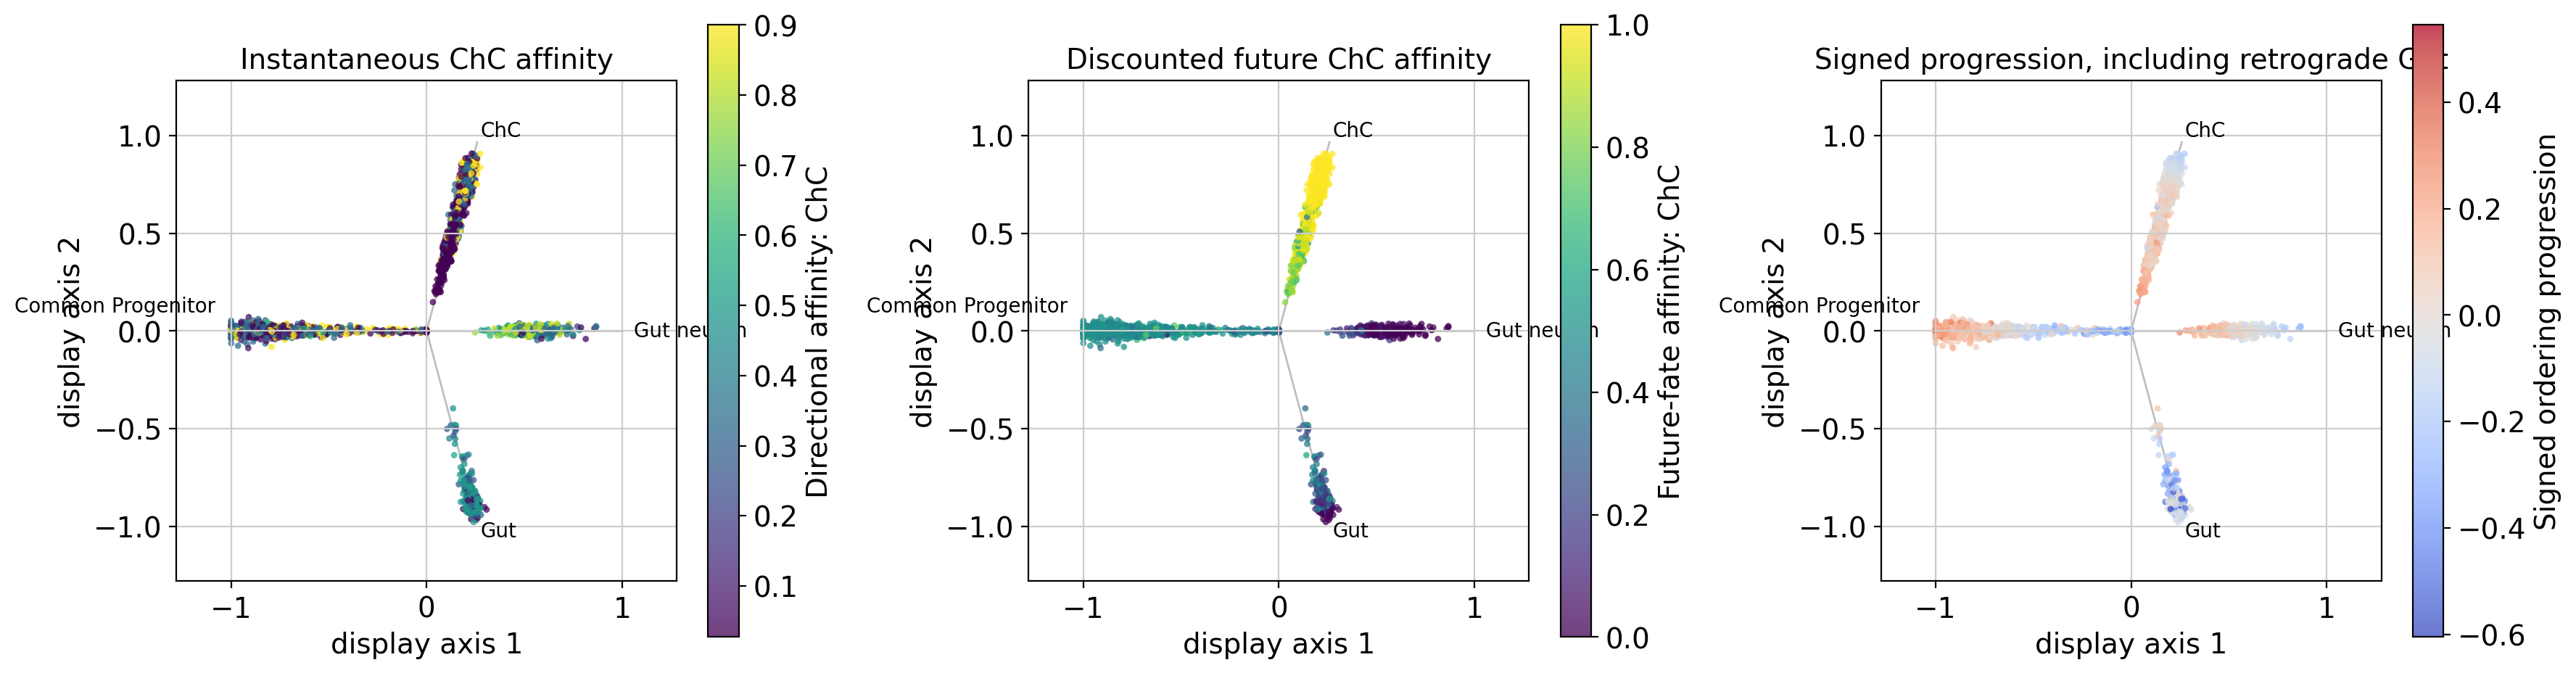

In [18]:
instantaneous = instantaneous_display_result
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
instantaneous_display_scorer.plot_star(
    instantaneous,
    color_by="affinity:ChC",
    title="Instantaneous ChC affinity",
    ax=axes[0],
)
scorer.plot_star(
    result,
    color_by="future_fate_affinity:ChC",
    title="Discounted future ChC affinity",
    ax=axes[1],
)
scorer.plot_star(
    result,
    color_by="signed_progression",
    title="Signed progression, including retrograde Gut",
    cmap="coolwarm",
    ax=axes[2],
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "instantaneous_vs_future_fate.png", dpi=200, bbox_inches="tight")
plt.show()

## 18. Export reproducible analysis objects


In [19]:
result.write_to_adata(adata)
adata.write_h5ad(OUTPUT_DIR / f"schwann_{VELOCITY_MODEL}_sccs_future_fate.h5ad")
cell_table = adata.obs.loc[result.cell_ids].copy()
cell_table["future_fate_reach"] = result.future_fate_reach
cell_table["future_fate_specificity"] = result.future_fate_specificity
cell_table["reach_supported_specificity"] = result.reach_supported_specificity
cell_table["signed_progression"] = result.signed_progression
cell_table["unresolved_probability"] = result.unresolved_probability
for fate_index, fate in enumerate(FATES):
    cell_table[f"future_fate_affinity_{fate}"] = result.future_fate_affinity[:, fate_index]
    cell_table[f"future_fate_contribution_{fate}"] = result.future_fate_contribution[:, fate_index]
cell_table.to_csv(OUTPUT_DIR / "cell_level_future_fate_scores.csv")
print("Saved outputs to", OUTPUT_DIR.resolve())

Saved outputs to /home/emil/notebooks/08-tutorials/tutorial_outputs/schwann_single


## 19. Interpretation checklist

- Inverse CytoTRACE is benchmark-specific, not a universal ordering recommendation.
- Gut retrograde progression is reported, not corrected away.
- Gut identity and Gut progression are separate questions.
- Root cells are generally low-specificity; hard dominant-fate labels should be
  restricted to sufficiently informative cells.
- Plate-level candidate-gene analyses require strong caveats about confounding.
